## **Abstract:**

A multinational wheat production and supply chain company that operates in important agricultural regions such as Brazil, India, Australia, the United States, Canada, and Syria. The business keeps an eye on market trends, environmental factors, and wheat crop yield in order to maximise pricing, distribution, and production plans.

**Main objective:**

Analyse the impact of environmental factors, soil characteristics and agricultural practices on wheat yield using predictive machine learning models.


**Specific objectives:**

- Using a supervised machine learning approach, develop and evaluate predictive models that accurately estimate wheat yield (tons/ha) based on environmental conditions, soil properties, fertilizer usage, and pest control.

- Identify the key factors that affect crop performance, such as climatic variables, fertilizer application, and pest management practices.

- Utilise descriptive and inferential statistical analyses to understand the distribution and relationships between relevant variables.

- Explore dimensionality reduction techniques, such as principal component analysis (PCA), to improve data interpretation and model efficiency.

- Finally, provide recommendations to enhance farmer satisfaction by addressing their key concerns.

  
The analysis will be splitted into three parts: Data Preparation, Statistical Techniques and Machine Learning Modeling. These analyses will help the company to understand customer preferences and enhance their services.




## **Data Dictionary**

![Data Dictionary](data_dictionary.png)

### 1) Import libraries needed

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statistics as stats
from sklearn.model_selection import train_test_split, cross_validate,ShuffleSplit
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


import warnings
warnings.filterwarnings('ignore') # We can suppress the warnings

### 2) Load the dataset

In [2]:
df = pd.read_excel("wheat_production_data.xlsx")

# <center>Data Preparation</center>

## **1)** Data Understanding:

Characterisation of the data set: size; number of attributes; has/does not have missing values, number of observations etc.


#### 1.1) To get an initial understanding of the data and to help identify the types of variables present, the first five rows of the dataframe are displayed.

In [3]:
df.head()

,Region,Weather Conditions,Soil Type,Fertilizer Usage (kg/ha),Crop Yield (tons/ha),Pest Infestation Level (%),Market Price per Ton ($),Production Cost ($/ha),Farmer Satisfaction Score
0,Europe,Cloudy,Silt,231.288932,5.254826,18.267238,401.139462,1525.682301,5
1,North America,Cloudy,Saline,97.797675,2.897609,13.959887,393.143675,1629.678271,2
2,Asia,Rainy,Saline,134.565776,4.284138,57.647244,450.476991,1591.178587,1
3,North America,Sunny,Loamy,127.174686,4.486818,76.188361,389.113840,1804.424687,3
4,North America,Rainy,Sandy,286.758997,6.522978,78.150565,192.736517,784.165150,5


**Preliminary observation of the dataset:** 

 1) The data contains information on various features relating to the region, weather conditions, soil type, crop yield, fertiliser usage, pest infestation, market price, production costs and farmer satisfaction regarding wheat production.

 2)   Most of the variables are continuous and take real numbers as values. Specifically, these include the following columns: **`Fertiliser Usage (kg/ha)`**, **`Crop Yield (tons/ha)`**, **`Pest Infestation Level (%)`**, **`Market Price per Ton ($)`** and **`Production Cost ($/ha)`**.

 3) The **`Farmer Satisfaction Score`** is the only discrete variable, taking on integer values. It is likely to be an ordinal categorical variable.

 
 4) **`Region`**, **`Weather Conditions`** and **`Soil Type`** are nominal categorical variables.

    
 5) The continuous numerical variables are measured in different units (e.g. `kg/ha`, `tons/ha`, `%`, `$` and `$/ha`), which indicates that they are on different scales.

#### 1.2) Look at summary information and shape of the DataFrame, such as index, type and columns, non-null values

In [4]:
df.shape

(900, 9)

**Note:** This means that our DataFrame contains 900 rows and 9 columns

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Region                      900 non-null    object 
 1   Weather Conditions          900 non-null    object 
 2   Soil Type                   900 non-null    object 
 3   Fertilizer Usage (kg/ha)    898 non-null    float64
 4   Crop Yield (tons/ha)        897 non-null    float64
 5   Pest Infestation Level (%)  898 non-null    float64
 6   Market Price per Ton ($)    897 non-null    float64
 7   Production Cost ($/ha)      899 non-null    float64
 8   Farmer Satisfaction Score   900 non-null    int64  
dtypes: float64(5), int64(1), object(3)
memory usage: 63.4+ KB


**Notes:** 

The following columns have nulls in them: `Fertilizer Usage (kg/ha)`, `Crop Yield (tons/ha)`,`Pest Infestation Level (%)`,`Pest Infestation Level (%)`,`Market Price per Ton ($)` and `Production Cost ($/ha)`.

The columns `Region`, `Weather Conditions` and `Soil Type` are of the object type, but they should be of the "category" type. Also, the `Farmer Satisfaction Score` is an 'int64' but it should be a 'category' type because it is a score.

##### 1.3) View summary statistics of our DataFrame's numeric columns

In [6]:
df.describe()

,Fertilizer Usage (kg/ha),Crop Yield (tons/ha),Pest Infestation Level (%),Market Price per Ton ($),Production Cost ($/ha),Farmer Satisfaction Score
count,898.000000,897.000000,898.000000,897.000000,899.000000,900.000000
mean,177.316221,5.071745,47.744286,298.814258,1240.919957,2.900000
std,72.951801,1.699855,29.074580,113.704917,441.624968,1.434906
min,50.047100,2.012111,0.018653,100.830607,500.941275,1.000000
25%,113.642189,3.668775,22.619756,202.037373,841.753127,2.000000
50%,181.511382,5.129596,46.394047,300.416095,1246.274640,3.000000
75%,240.425548,6.522404,73.022586,396.919503,1600.994657,4.000000
max,299.928451,7.978390,99.762282,499.619799,1999.773867,5.000000


**Notes:** 

**Column:** `Pest Infestation Level (%)` suggests there is a large spread in the data.

**Column:** `Crop yield (tons/ha)` has a mean of 5.071745 and a median of 5.129596. These values are close but not equal to each other, suggesting that the data is roughly symmetrical but not necessarily normally distributed. A histogram would provide a clearer perspective of this. The same approach should be applied to the remaining columns to assess their distributions in more detail.

**Column:** `Farmer Satisfaction Score`: the minimum and maximum values indicate that the scores range from 1 to 5.




#### 1.4) View summary statistics of our DataFrame's object columns

In [7]:
df.describe( include = "object")

,Region,Weather Conditions,Soil Type
count,900,900,900
unique,6,5,5
top,Europe,Drought,Saline
freq,161,190,201


**Notes:** 

According to the data dictionary, there should be five regions, but the summary statistics of the object columns in our dataframe indicate that there are six unique values in the `Region` column. This discrepancy will need to be investigated by visualising the unique values, as will the `Weather Conditions` and `Soil Type` columns, since there may be spelling errors.

#### 1.5) Visualise the unique values of  "Region", "Weather Conditions" and "Soil Type"

In [8]:
unique_r = df["Region"].unique()
print("Regions:", unique_r)

Regions: ['Europe' 'North America' 'Asia' 'Australia' 'Africa' 'South America']


In [9]:
unique_w = df["Weather Conditions"].unique()
print("Weather Conditions:", unique_w)

Weather Conditions: ['Cloudy' 'Rainy' 'Sunny' 'Drought' 'Stormy']


In [10]:
unique_s = df["Soil Type"].unique()
print("Soil Types:", unique_s)

Soil Types: ['Silt' 'Saline' 'Loamy' 'Sandy' 'Peaty']


**Notes:** 

There are no spelling errors in any of the columns mentioned before, and as we can see, the correct regions of our dataset are shown above.

## 2) Data Preparation

Application of Data preparation/evaluation methods (Cleaning, renaming, etc) and EDA (Exploratory Data Analysis) visualizations (plural), including a clear and concise explanation of your rationale for what you are doing with the data and why you are doing it.

#### 2.1) Renaming columns makes them more descriptive and practical, which makes them easier to use and understand during data analysis.

In [11]:
df = df.rename(columns = {
    "Region": "region", 
    "Weather Conditions":"weather",
    "Soil Type": "soil_type", 
    "Fertilizer Usage (kg/ha)":"fertilizer_u",
    "Crop Yield (tons/ha)":"yield",
    "Pest Infestation Level (%)":"pest_level",
    "Market Price per Ton ($)":"market_price",
    "Production Cost ($/ha)":"cost_prod",
    "Farmer Satisfaction Score":"score",
})

## 2.2) Review of the changes 

In [12]:
df.head()

,region,weather,soil_type,fertilizer_u,yield,pest_level,market_price,cost_prod,score
0,Europe,Cloudy,Silt,231.288932,5.254826,18.267238,401.139462,1525.682301,5
1,North America,Cloudy,Saline,97.797675,2.897609,13.959887,393.143675,1629.678271,2
2,Asia,Rainy,Saline,134.565776,4.284138,57.647244,450.476991,1591.178587,1
3,North America,Sunny,Loamy,127.174686,4.486818,76.188361,389.113840,1804.424687,3
4,North America,Rainy,Sandy,286.758997,6.522978,78.150565,192.736517,784.165150,5


## 2.3) Determine whether there are outliers

In [13]:
df.columns

Index(['region', 'weather', 'soil_type', 'fertilizer_u', 'yield', 'pest_level',
       'market_price', 'cost_prod', 'score'],
      dtype='object')

##### Firstly: Create two lists: one for numerical variables and one for categorical variables.

In [14]:
cat_columns = ['region', 'weather', 'soil_type','score']

num_columns = ['fertilizer_u', 'yield', 'pest_level','market_price', 'cost_prod']


##### Secondly: Calculate the frequency count of levels in categorical variables to examine how the values of each categorical feature are distributed.

In [15]:
for col in cat_columns:
    print(df[col].value_counts())

region
Europe           161
South America    161
North America    155
Australia        144
Asia             141
Africa           138
Name: count, dtype: int64
weather
Drought    190
Stormy     184
Rainy      183
Cloudy     180
Sunny      163
Name: count, dtype: int64
soil_type
Saline    201
Loamy     195
Silt      187
Sandy     167
Peaty     150
Name: count, dtype: int64
score
1    205
2    191
4    173
5    169
3    162
Name: count, dtype: int64


**Notes:** All levels in all categorical variables are almost equally distributed, with no significant disparities.

##### Thirdly: Box plots are used to detect outliers and visualise the spread of numerical variables more effectively.

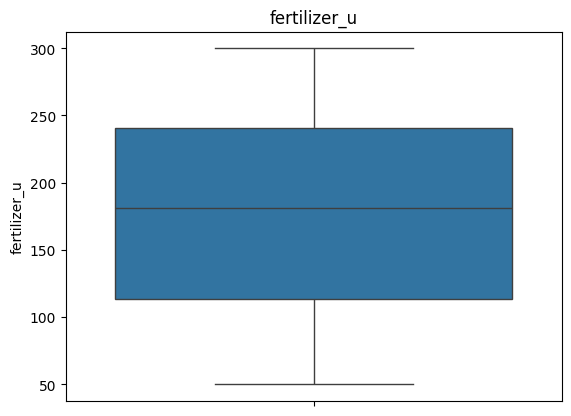

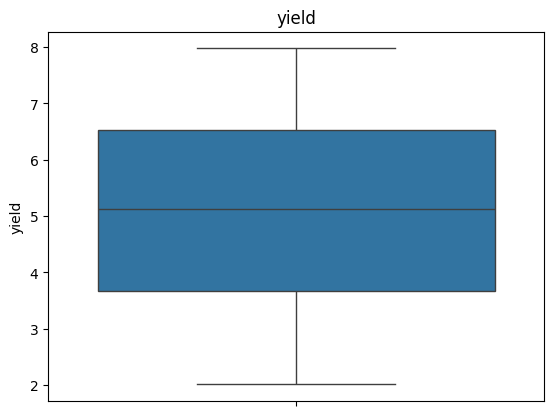

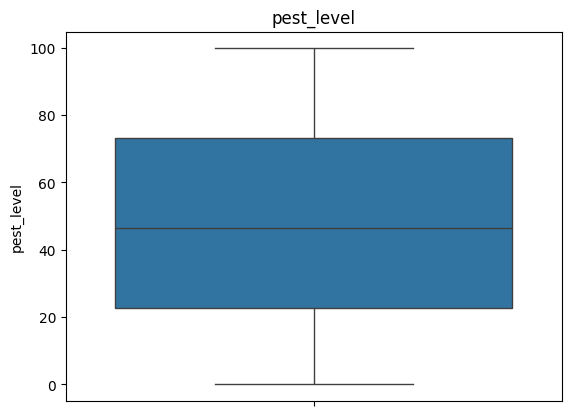

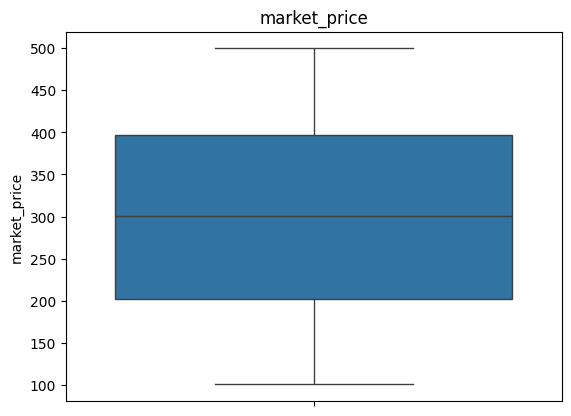

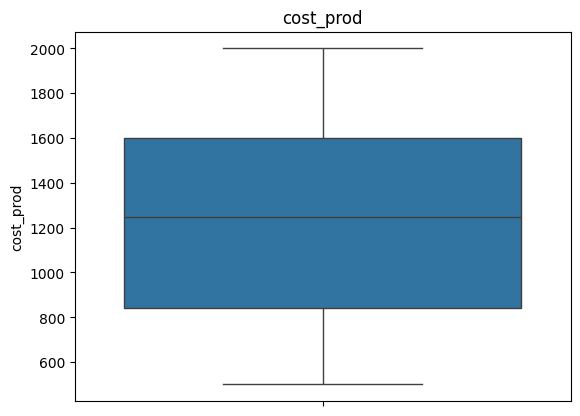

In [16]:
for col in num_columns:
    sns.boxplot(df[col])
    plt.title(col)
    plt.show()

**Notes:** 

- All numerical features have symmetrical distributions.
- There are no outliers present in any of them.

## 2.4) Data cleaning

##### Check if there are any missing values in each column.

In [17]:
missing_counts = df.isnull().sum()
print("Missing values in each column:")
print(missing_counts)


Missing values in each column:
region          0
weather         0
soil_type       0
fertilizer_u    2
yield           3
pest_level      2
market_price    3
cost_prod       1
score           0
dtype: int64


##### Calculate the percentage of missing values for each column.

In [18]:
null_percentages = (df.isnull().sum() / len(df)) * 100
print("Percentage of missing values in each column:")
print(null_percentages)


Percentage of missing values in each column:
region          0.000000
weather         0.000000
soil_type       0.000000
fertilizer_u    0.222222
yield           0.333333
pest_level      0.222222
market_price    0.333333
cost_prod       0.111111
score           0.000000
dtype: float64


**Notes:** 

The percentage of missing values in **`fertilizer_u`**, **`yield`**, **`pest_level`**, **`market_price`** and **`cost_prod`** is very small -all are below 0.5% of the total- so I will drop the rows containing these missing values.


##### Drop rows with missing values.

In [19]:
df = df.dropna()
print("Number of rows after data cleaning:")
print(df.shape)

Number of rows after data cleaning:
(890, 9)


##### Handling duplicate rows

In [20]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
895    False
896    False
897    False
898    False
899    False
Length: 890, dtype: bool

In [21]:
duplicates = df.duplicated().sum()

print(f"Total of duplicates:{duplicates}")


Total of duplicates:0


**Notes:** 

This dataset does not contain any duplicate values.

## 2.5) Data Exploratory Analysis (EDA)

##### **Question to be answered:**

#### What factors influence wheat yield in this dataset?

### Bivariate Exploratory Analysis

If we simply want to visualize the correlation between variables, we can use a correlation matrix. This matrix displays both the magnitude and direction (positive or negative) of the correlation, with correlation coefficients ranging from -1 to 1. (Molin, 2021)


- **1** = There is a perfect positive linear relationship between the variables. This means that if one variable increases, the crop yield will increase by the same amount.
  
- **0** = there is no linear relationship between the variables

- **-1** = There is a perfect negative linear relationship between the variables. This means that if one variable increases, the crop yield will decrease by the same amount, and vice versa.

###  Bivariate Exploratory Analysis: Numerical - numerical 

**Plot correlation matrix for numerical features:** Which numerical variables are closely related to the predicted wheat yield? According to the correlation matrix, which of these variables have correlation values close to +1 or -1?

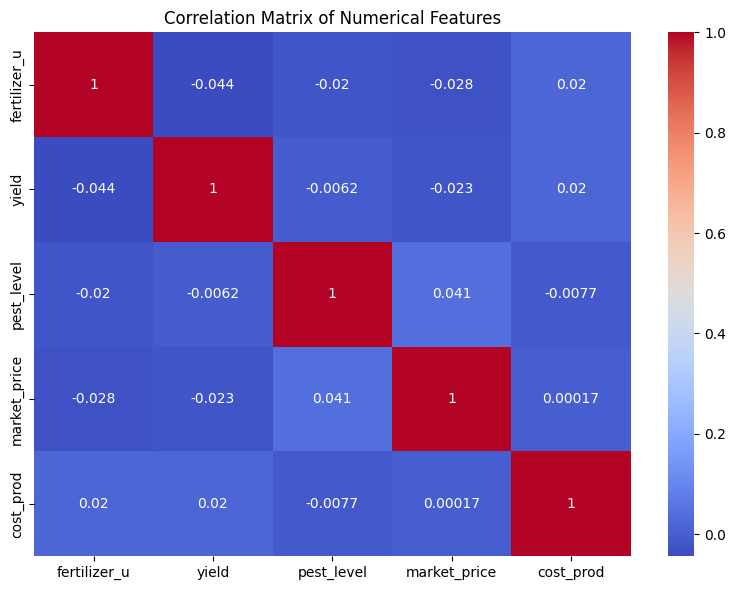

In [22]:
plt.figure(figsize=(8, 6))  
sns.heatmap(df[num_columns].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout() 
plt.savefig("correlation_matrix.png", dpi=300)  
plt.show()


**Answer:** As there was a low linear correlation (close to zero) between all the features (fertiliser usage, pest infestation level, market price and production cost) and crop yield (the target variable), it can be concluded that a linear regression model would be inappropriate as there is no linear relationship between the variables and crop yield.

### Bivariate Exploratory Analysis: Categorical - numerical 

#### Is wheat crop yield (tons/ha) influenced by region?


**Objective:** Calculate the average wheat yield for each region and visualize the results using a bar chart to highlight regional differences in performance. 

**Steps:**

1) Group the data by region and compute the mean of the crop yield.
2) Plot the results using a bar chart

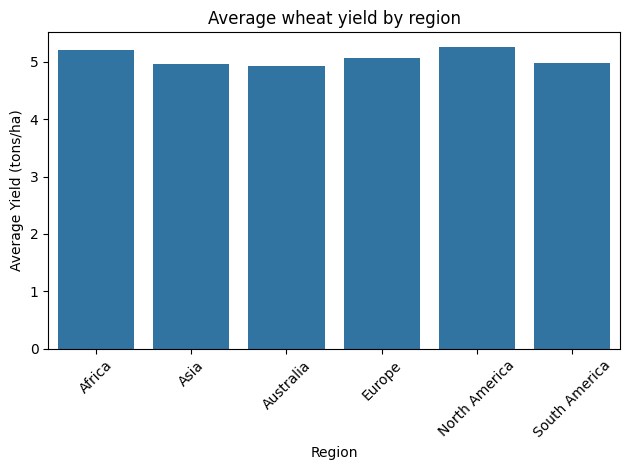

In [23]:
df_region = df.groupby("region")["yield"].mean()

sns.barplot(x = df_region.index, y = df_region.values)
plt.title("Average wheat yield by region")
plt.xlabel("Region")
plt.ylabel("Average Yield (tons/ha)")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

**Notes:**

**1)** There are no significant differences in the mean yield of wheat crops between regions.

**2)** The region does not seem to be a relevant feature for predicting crop yield.

#### Is wheat crop yield (tons/ha) influenced by weather conditions?

**Objective:** Calculate the average wheat yield for each weather conditions and visualize the results using a bar chart to highlight performance differences.

**Steps:**

1) Group the data by weather conditions and compute the mean of the crop yield.
2) Plot the results using a bar chart.

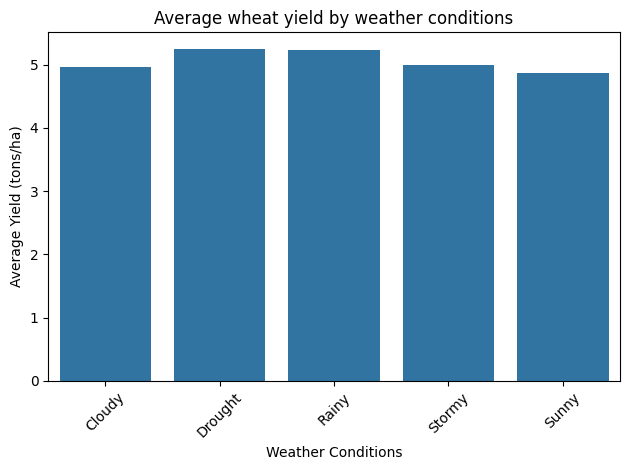

In [24]:
df_weather = df.groupby("weather")["yield"].mean()

sns.barplot(x = df_weather.index, y = df_weather.values)
plt.title("Average wheat yield by weather conditions")
plt.xlabel("Weather Conditions")
plt.ylabel("Average Yield (tons/ha)")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

**Notes:**

**1)** There are no significant differences in the mean crop yield under different weather conditions.

**2)**  The weather does not seem to be a relevant factor in predicting crop yield.

#### Is wheat crop yield (tons/ha) influenced by soil type?

**Objective:** Calculate the average wheat yield for each soil type and visualize the results using a bar chart to highlight performance differences.

**Steps:**

1) Group the data by soil type and compute the mean of the crop yield.
2) Plot the results using a bar chart.

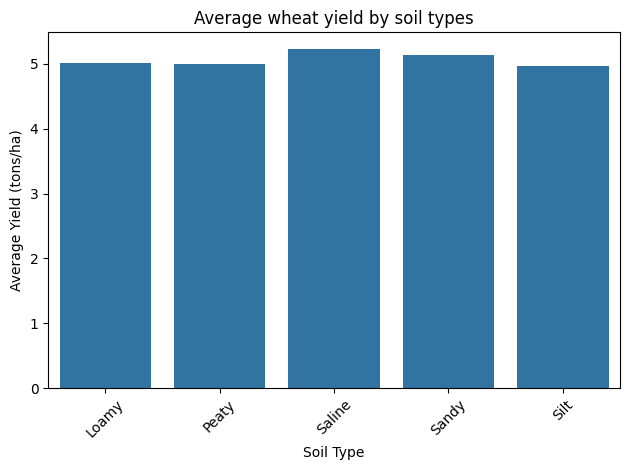

In [25]:
df_soil = df.groupby("soil_type")["yield"].mean()

sns.barplot(x = df_soil.index, y = df_soil.values)
plt.title("Average wheat yield by soil types")
plt.xlabel("Soil Type")
plt.ylabel("Average Yield (tons/ha)")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

**Notes:**

**1)** There are no significant differences in the mean crop yield for different soil conditions.

**2)**  Soil type does not seem to be a relevant factor in predicting crop yield.

#### **Bivariate analysis conclusion:**

The bivariate analysis of the categorical variables (region, climate and soil type) revealed no strong or consistent influence on wheat crop yield. While some minor variations in average yield were observed, none were significant.

This suggests that wheat yield is affected by a variety of factors rather than a single one. A multivariate analysis is necessary to examine the interactions between these variables and capture the more complex relationships that may affect crop performance.

## Exploratory Analysis of Crop Yield by Region and Weather Conditions

#### How do region and weather conditions influence wheat crop yield (tons/ha)?

In order to answer this question, it is helpful to consider the interaction between regions and weather conditions, and their effect on wheat yield.

One effective way to visualise this relationship is to use a stacked or clustered bar chart. To create this type of graph, we use the pandas unstack() method to transform the data from a multi-index into a plotable format.

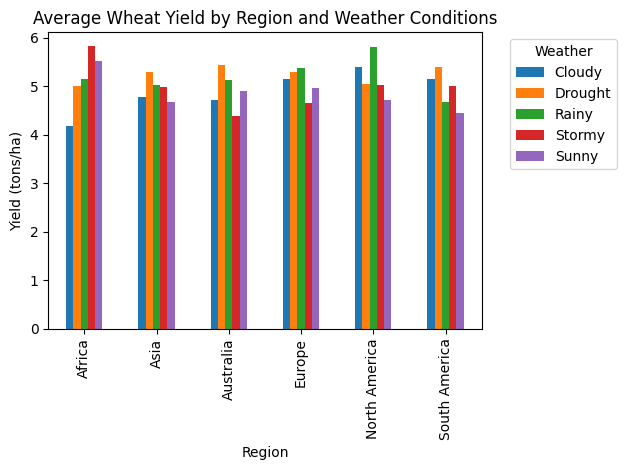

In [26]:
df_region_weather = df.groupby(["region", "weather"])["yield"].mean()

df_region_weather.unstack().plot(kind = "bar", stacked = False)
plt.title("Average Wheat Yield by Region and Weather Conditions")
plt.ylabel("Yield (tons/ha)")
plt.xlabel("Region")
plt.legend(title="Weather", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Notes:** 

**1)** It seems that Africa is more sensitive to weather variations: stormy seasons may increase crop yields, whereas cloudy weather appears to reduce them.

**2)** However, no clear correlation has been found between specific regions and weather patterns that have a marked effect on crop yield.

**3)** Further analysis may be required to investigate potential underlying factors that could influence crop yields, such as soil type by region.

## Exploratory Analysis of Crop Yield by Region and Soil Type

#### What is the relationship between region, soil type, and wheat crop yield (tons/ha)?

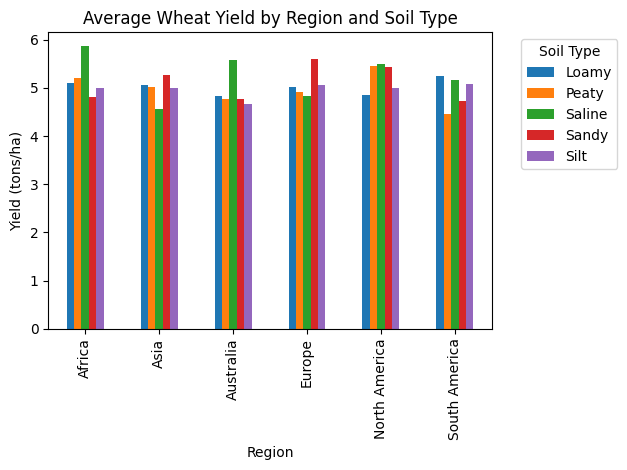

In [27]:
df_region_soil = df.groupby(["region", "soil_type"])["yield"].mean()

df_region_soil.unstack().plot(kind = "bar", stacked = False)
plt.title("Average Wheat Yield by Region and Soil Type")
plt.ylabel("Yield (tons/ha)")
plt.xlabel("Region")
plt.legend(title="Soil Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Notes:** 

**1)** Regions such as Africa, Australia and North America appear to exhibit greater variation in wheat yields depending on soil type. Saline soils, in particular, are associated with higher yields in these regions.

**2)** However, this trend is not consistent across all regions. For example, in Asia and South America, yields remain relatively stable regardless of soil type. This suggests that there is no strong or universal pattern linking regions and soil types to yield.


## Exploratory Analysis of Crop Yield by Soil Type and Weather Conditions

#### How do soil type and weather conditions influence wheat crop yield (tons/ha)?

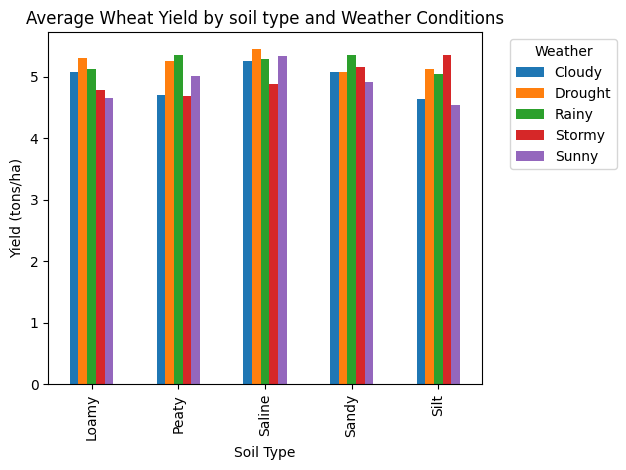

In [28]:
df_soil_weather = df.groupby(["soil_type", "weather"])["yield"].mean()

df_soil_weather.unstack().plot(kind = "bar", stacked = False)
plt.title("Average Wheat Yield by soil type and Weather Conditions")
plt.ylabel("Yield (tons/ha)")
plt.xlabel("Soil Type")
plt.legend(title="Weather", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Notes:** 

**1)** Saline soil appears to be more sensitive to weather variations, showing greater variation in crop yield across different weather conditions.

**2)** Overall, rainy and drought conditions tend to be associated with slightly higher yields in most soil types, while sunny and cloudy conditions generally correspond to lower yields.

**3)** However, no single soil-weather combination leads to the highest yield consistently, suggesting that wheat crop performance is influenced by multiple interacting factors.

## Multivariate Visualization of Wheat Yield, Fertilizer Usage, and Pest Infestation Across Regions

To understand how the variables are related to each other in this exploratory analysis of the dataset, a multivariate visualization can be used to look for complex patterns through `relplot()`. This figure-level function visualizes the complex statistical relationships of data sets. It plots two-dimensional plots that can be enhanced by assigning up to three additional variables using hue, size, and style semantics (Waskom, n.d.).

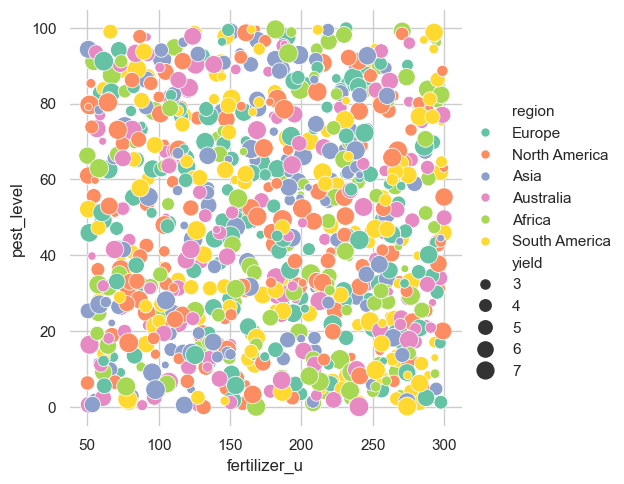

In [29]:
sns.set_theme(style="whitegrid")

g = sns.relplot(
    data=df,
    x="fertilizer_u", 
    y="pest_level",
    hue="region", 
    size="yield",
    sizes=(30, 200),
    palette="Set2"
)

g.ax.xaxis.grid(True, "minor", linewidth=.25)
g.ax.yaxis.grid(True, "minor", linewidth=.25)
g.despine(left=True, bottom=True)


**Notes:**

In the event that a clearly distinguishable pattern were present—such as consistently high yields in certain regions and low yields in others—it would be possible to conclude that a meaningful relationship exists among the variables. However, since no such pattern has emerged, we conclude that a clear relationship has yet to be identified.

#### **Multivariate exploratory analysis conclusion:**

Based on the exploratory analysis, no clear or consistent patterns were observed among the variables that could reliably predict wheat yield. As a result, more advanced analytical approaches—such as Principal Component Analysis (PCA) or machine learning techniques—are appropriate to further explore the data and uncover potential predictive relationships.

However, it is important to acknowledge that applying PCA  may reduce interpretability. As Müller and Guido (2016) explain, PCA is an unsupervised method that does not consider class information when computing the component axes; instead, it relies solely on the correlations within the data.

Even so, dimensionality reduction techniques will be explored to assess whether they can enhance the prediction of wheat yield.



## 3) Data Preprocessing and Feature Engineering:

Apply encoding, scaling and feature engineering as and if required, detailing how and why you used these techniques and the rationale for your decisions.

#### **3.1)** The 'Farmer Satisfaction Score' column will be excluded from the dataset, as it does not fulfil the criteria of a predictor variable.

In [30]:
df_copy = df.copy()
df_copy = df_copy.drop(columns=["score"])
df_copy

,region,weather,soil_type,fertilizer_u,yield,pest_level,market_price,cost_prod
0,Europe,Cloudy,Silt,231.288932,5.254826,18.267238,401.139462,1525.682301
1,North America,Cloudy,Saline,97.797675,2.897609,13.959887,393.143675,1629.678271
2,Asia,Rainy,Saline,134.565776,4.284138,57.647244,450.476991,1591.178587
3,North America,Sunny,Loamy,127.174686,4.486818,76.188361,389.113840,1804.424687
4,North America,Rainy,Sandy,286.758997,6.522978,78.150565,192.736517,784.165150
...,...,...,...,...,...,...,...,...
895,Australia,Stormy,Silt,134.241181,2.936215,10.540529,305.609348,1861.626200
896,North America,Drought,Loamy,299.885980,7.007546,55.382344,342.301492,1594.655767
897,Australia,Sunny,Silt,151.437792,4.150008,51.297935,352.752064,1603.195293
898,Asia,Rainy,Loamy,105.122109,7.477355,28.139298,310.820063,620.027405


#### **3.2)** **Encoding:**

As PCA, LDA, and machine learning algorithms require numerical input, the categorical variables `region`, `weather`, and `soil_type` will be converted to dummy (indicator) variables using one-hot encoding, as these features are nominal.

In [31]:
cat_columns = ["region", "weather", "soil_type"]
df_copy = pd.get_dummies(df_copy, columns=cat_columns, dtype=float)
df_copy

,fertilizer_u,yield,pest_level,market_price,cost_prod,region_Africa,region_Asia,region_Australia,region_Europe,region_North America,...,weather_Cloudy,weather_Drought,weather_Rainy,weather_Stormy,weather_Sunny,soil_type_Loamy,soil_type_Peaty,soil_type_Saline,soil_type_Sandy,soil_type_Silt
0,231.288932,5.254826,18.267238,401.139462,1525.682301,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,97.797675,2.897609,13.959887,393.143675,1629.678271,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,134.565776,4.284138,57.647244,450.476991,1591.178587,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,127.174686,4.486818,76.188361,389.113840,1804.424687,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
4,286.758997,6.522978,78.150565,192.736517,784.165150,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,134.241181,2.936215,10.540529,305.609348,1861.626200,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
896,299.885980,7.007546,55.382344,342.301492,1594.655767,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
897,151.437792,4.150008,51.297935,352.752064,1603.195293,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
898,105.122109,7.477355,28.139298,310.820063,620.027405,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


#### **3.3)** **Preparing Data for Dimensionality Reduction and Modeling**

In order to facilitate the division of the data between the independent variables and the target, the `yield` column should be moved to the right-hand side of the dataframe.

In [32]:
col_crop_yield = df_copy.loc[:,"yield"]
df_copy.drop(columns="yield", inplace=True)
df_copy["yield"] = col_crop_yield
df_copy

,fertilizer_u,pest_level,market_price,cost_prod,region_Africa,region_Asia,region_Australia,region_Europe,region_North America,region_South America,...,weather_Drought,weather_Rainy,weather_Stormy,weather_Sunny,soil_type_Loamy,soil_type_Peaty,soil_type_Saline,soil_type_Sandy,soil_type_Silt,yield
0,231.288932,18.267238,401.139462,1525.682301,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5.254826
1,97.797675,13.959887,393.143675,1629.678271,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.897609
2,134.565776,57.647244,450.476991,1591.178587,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,4.284138
3,127.174686,76.188361,389.113840,1804.424687,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,4.486818
4,286.758997,78.150565,192.736517,784.165150,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,6.522978
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,134.241181,10.540529,305.609348,1861.626200,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,2.936215
896,299.885980,55.382344,342.301492,1594.655767,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,7.007546
897,151.437792,51.297935,352.752064,1603.195293,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,4.150008
898,105.122109,28.139298,310.820063,620.027405,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,7.477355


#### **3.4)** **Scaling:**

According to Molin (2021), when all features are considered valuable, it is preferable to apply feature extraction rather than discard variables entirely. Principal Component Analysis (PCA) achieves this by projecting high-dimensional data onto a lower-dimensional space, thereby reducing dimensionality while retaining as much variance as possible. However, since PCA is sensitive to the scale of the variables, appropriate preprocessing is required to avoid distortion of the results. Gatsoulis (2016) supports this, emphasising that scaling ensures the principal components capture true variation across features without being disproportionately influenced by those with higher original variance.

Taking this into account, and given that both Principal Component Analysis (PCA) require properly scaled numerical inputs, I will proceed with standardising the numerical variables. This will ensure that all features contribute appropriately to the analysis.



### SatandardScaler


The StandardScaler in scikit-learn ensures that the mean is 0 and the variance is 1 for each feature, thereby bringing all features to the same magnitude. However, this scaling does not guarantee specific minimum or maximum values for the features (Müller and Guido, 2016)

Both PCA and LDA rely on feature variance. These techniques are highly sensitive to the scale of the input variables. Since the variables in this dataset have different units of measurement, applying StandardScaler normalizes each variable to have a mean of 0 and a standard deviation of 1, allowing all variables to contribute equally to the principal components in PCA and to class separation in LDA. This prevents variables with larger numeric ranges from dominating.

**3.4.1)** Create a new DataFrame for PCA and LDA analysis

In [33]:
df_scaled = df_copy.copy()

**3.4.2)** Split the data

In [34]:
X = df_scaled.iloc[:, :-1]  
y = df_scaled.iloc[:, -1]   
X.shape, y.shape

((890, 20), (890,))

**3.4.3)** Scale only the features

In [35]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


**3.4.4)** Convert back to a DataFrame for easier interpretation

In [36]:
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

**3.4.5)** Check the changes and compare them with the original dataset, for example, the `fertilizer_u` column.

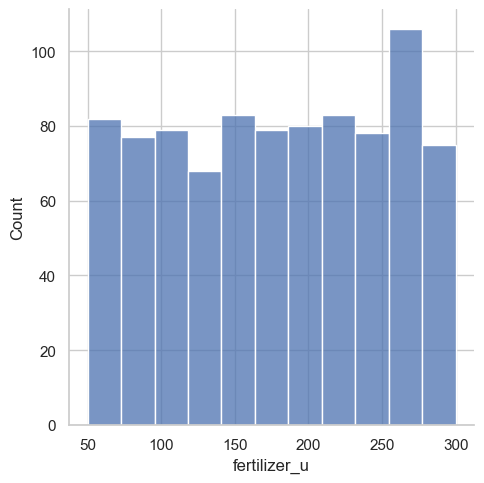

In [37]:
sns.displot(df_copy, x="fertilizer_u")


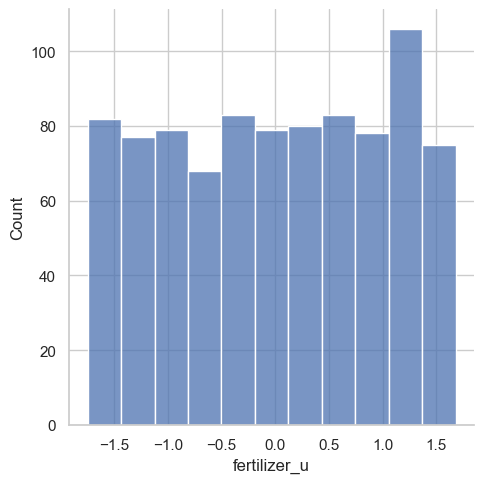

In [38]:
sns.displot(X_scaled_df, x="fertilizer_u")


## 4) LDA  (Linear Discriminant Analysis) & PCA (Principal Component Analysis):

**4.1)** Explore the possibility of using dimensional reduction on the dataset. Employ both LDA (Linear Discriminant Analysis) and PCA (Principal Component Analysis) and compare the separation of classes through visualization. Explain the difference between both techniques in your own words and discuss in detail how your results may affect your analysis of classifying, clustering or prediction.

**Answer:**

Müller and Guido (2016) argue that there are many reasons to transform data using unsupervised learning. The most common reasons are visualization, compression, and creating a more informative representation for further processing. One of the simplest and most widely used algorithms for these purposes is **Principal Component Analysis (PCA)**. PCA is a technique that reduces the dimensionality of an original dataset by rotating it so that the resulting components, called principal components, are uncorrelated. After this transformation, a subset of the components can be selected based on how well they explain the total variance. This process reduces superfluous features while preserving most of the essential information in the data (Müller & Guido, 2016).

In contrast, **Linear Discriminant Analysis (LDA)** is a supervised technique that seeks to project the data into a lower-dimensional space by maximizing the separation between known classes. However, it can only be used if the labels represent categorical classes.

Since the goal of this analysis is to predict wheat yield, a regression problem, LDA is not applicable. Nevertheless, PCA remains a valuable tool for exploring data structure, reducing noise or redundancy, and potentially improving model performance by highlighting the most informative directions in the feature space.

### **4.2)** **Principal Component Analysis (PCA)**

**Define how many components do I need**

The Cumulative Explained Variance Ratio is a function that helps estimate the optimal number of components or variables needed in PCA to adequately describe the data set. PCA captures the variance present in the original data frame and encodes it into new variables (principal components) that preserve the underlying patterns and structure of the data. The cumulative explained variance indicates how much of the total variance is retained as more components are included.

The next step is to determine the number of components required to maintain 99.5% of the variance in the data.

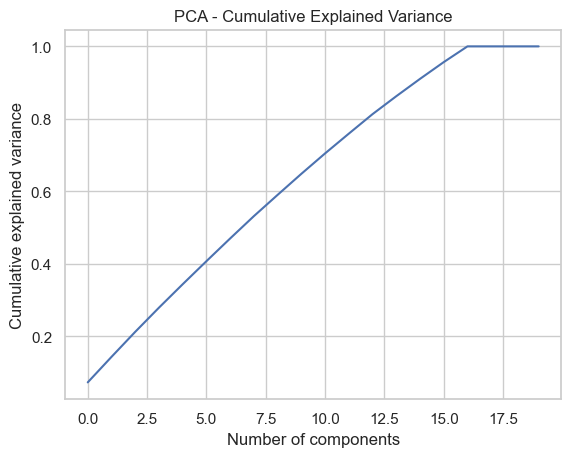

In [39]:
pca = PCA().fit(X_scaled_df)
plt.plot(np.cumsum(pca.explained_variance_ratio_)) 
plt.xlabel('Number of components') 
plt.ylabel('Cumulative explained variance')
plt.title('PCA - Cumulative Explained Variance')
plt.grid(True)
plt.show()

In [40]:
pca = PCA(0.995)
projected = pca.fit_transform(X_scaled_df)

In [41]:
projected.shape

(890, 17)

**Notes:**

PCA has extracted the underlying patterns from the original data set and transformed the data into a new set of features (principal components) that retain 99.5% of the original variance. The optimal number of new features required is 17.

**We create a new data frame to visualise projected:**

In [42]:
df_pca = pd.DataFrame(projected, columns =['C1', 'C2', 'C3', 'C4','C5','C6','C7','C8','C9','C10','C11','C12','C13','C14','C15','C16','C17'])

In [43]:
df_pca.head()

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,C15,C16,C17
0,1.251122,-1.527042,1.011701,-1.527313,-0.141942,0.480188,-1.446299,0.721557,-1.232332,-0.354082,-0.159717,-1.866619,0.431044,-1.045229,0.512834,-1.058952,0.340887
1,-1.986029,-1.135996,0.862168,-0.788959,0.286195,-1.166320,0.003575,-0.789261,0.244253,1.653164,-0.513294,-0.859018,1.595009,-1.106887,0.853316,-1.158244,-0.969045
2,-2.459979,-0.075473,-1.641024,0.312732,0.208471,-0.969369,1.117591,0.435489,-0.856109,-0.962245,0.656259,-1.087335,-0.429599,0.582341,1.761342,-0.667690,-0.191954
3,-0.372347,0.847152,0.245660,-0.458309,-0.926902,-1.296158,-0.738340,1.023870,1.051104,3.095079,0.570366,-0.283979,-0.036748,1.292106,0.585405,0.924368,-0.612734
4,-2.311971,1.039585,0.325637,1.721694,-1.075977,1.394901,-0.984771,-0.699512,-0.122246,0.578558,0.136652,-0.259685,0.353226,-0.231824,-0.633949,1.289373,2.167871


In [44]:
df_pca.index = df_scaled.index  
df_pca["yield"] = df_scaled["yield"]


In [45]:
print(df_pca.isnull().sum())

C1       0
C2       0
C3       0
C4       0
C5       0
C6       0
C7       0
C8       0
C9       0
C10      0
C11      0
C12      0
C13      0
C14      0
C15      0
C16      0
C17      0
yield    0
dtype: int64


The target variable (`yield`) has been included in the new DataFrame in order to align it with the transformed features and prevent any missing values or index mismatches during model testing.

In [46]:
df_pca.head()

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,C15,C16,C17,yield
0,1.251122,-1.527042,1.011701,-1.527313,-0.141942,0.480188,-1.446299,0.721557,-1.232332,-0.354082,-0.159717,-1.866619,0.431044,-1.045229,0.512834,-1.058952,0.340887,5.254826
1,-1.986029,-1.135996,0.862168,-0.788959,0.286195,-1.166320,0.003575,-0.789261,0.244253,1.653164,-0.513294,-0.859018,1.595009,-1.106887,0.853316,-1.158244,-0.969045,2.897609
2,-2.459979,-0.075473,-1.641024,0.312732,0.208471,-0.969369,1.117591,0.435489,-0.856109,-0.962245,0.656259,-1.087335,-0.429599,0.582341,1.761342,-0.667690,-0.191954,4.284138
3,-0.372347,0.847152,0.245660,-0.458309,-0.926902,-1.296158,-0.738340,1.023870,1.051104,3.095079,0.570366,-0.283979,-0.036748,1.292106,0.585405,0.924368,-0.612734,4.486818
4,-2.311971,1.039585,0.325637,1.721694,-1.075977,1.394901,-0.984771,-0.699512,-0.122246,0.578558,0.136652,-0.259685,0.353226,-0.231824,-0.633949,1.289373,2.167871,6.522978


**After checking for null values and inspecting the header of the DataFrame, it is ready for modelling with all the principal components and the target variable included and with no missing values.**

**Note:**

The Random Forest Regressor was chosen because it can capture nonlinear relationships between variables and is robust to complex data without requiring strong assumptions about its distribution. In order to align with the requirements of the Machine Learning module, the model will be implemented using hyperparameter tuning via GridSearchCV. It will then be evaluated using two different train-test splits (75/25 and 80/20) and validated using 10-fold cross-validation. This method provides a more robust and statistically reliable performance estimate by averaging results across multiple data partitions.

#### 1) Define the features and targets, and create two training and testing splits (75% training / 25% testing and 80% training / 20% testing)

In [47]:
X = df_pca.drop("yield", axis=1)  
y = df_pca["yield"]               

In [48]:
X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, test_size=0.25, random_state=123)

X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.20, random_state=456)

In [49]:
X_train1.shape, X_test1.shape, y_train1.shape, y_test1.shape

((667, 17), (223, 17), (667,), (223,))

In [50]:
X_train2.shape, X_test2.shape, y_train2.shape, y_test2.shape

((712, 17), (178, 17), (712,), (178,))

### 2) Hyperparameter tuning with GridSearchCV

In [51]:
param_grid = {
    'n_estimators': [100, 200],          # Number of trees
    'max_depth': [None, 10, 20],         # Tree depth
    'min_samples_split': [2, 5]          # Minimum samples to split a node
}

# 5-fold cross-validation for hyperparameter tuning
grid_rf = GridSearchCV(RandomForestRegressor(random_state=123),
                       param_grid,
                       cv=5,
                       scoring='neg_root_mean_squared_error',
                       n_jobs=-1)

grid_rf.fit(X_train1, y_train1)          # Train on first split
best_rf = grid_rf.best_estimator_        # Get best model

### 3) Evaluation function for Random Forest on different data splits

In [52]:
def evaluate_model(name, model, X_test, y_test):
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    return {
        "Model": name,
        "RMSE": rmse,
        "R2": r2,
        "MAE": mae
    }

### 4)  Evaluate model on both train-test splits

In [53]:
results_pca = []

results_pca.append(evaluate_model("Random Forest (PCA, 75/25)", best_rf, X_test1, y_test1))
results_pca.append(evaluate_model("Random Forest (PCA, 80/20)", best_rf, X_test2, y_test2))


### 5) 10-fold cross-validation on entire dataset

In [54]:
cv = KFold(n_splits=10, shuffle=True, random_state=123)

cv_results_pca = cross_validate(
    best_rf, X, y,
    scoring={
        'rmse': 'neg_root_mean_squared_error',
        'r2': 'r2',
        'mae': 'neg_mean_absolute_error'
    },
    cv=cv,
    return_train_score=False
)

results_pca.append({
    "Model": "Random Forest (PCA, CV-10)",
    "RMSE": -cv_results_pca['test_rmse'].mean(),
    "R2": cv_results_pca['test_r2'].mean(),
    "MAE": -cv_results_pca['test_mae'].mean()
})


### 6)  Display the results in a table and provide a visual comparison of the RMSE.

                        Model      RMSE        R2       MAE
0  Random Forest (PCA, 75/25)  1.773829 -0.079479  1.514649
1  Random Forest (PCA, 80/20)  1.235315  0.482974  0.997080
2  Random Forest (PCA, CV-10)  1.743559 -0.070711  1.494054


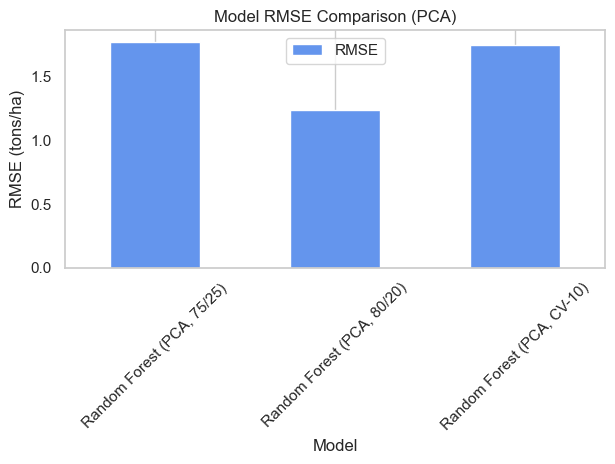

In [55]:
results_pca_df = pd.DataFrame(results_pca)
print(results_pca_df)

results_pca_df.set_index("Model")[["RMSE"]].plot(
    kind="bar",
    color="cornflowerblue",
    title="Model RMSE Comparison (PCA)"
)
plt.ylabel("RMSE (tons/ha)")  
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


### 7) Overfitting Evaluation

In [56]:
best_rf.fit(X_train1, y_train1)

train_preds = best_rf.predict(X_train1)
train_rmse = np.sqrt(mean_squared_error(y_train1, train_preds))
print(f"Train RMSE (75/25 split): {train_rmse:.2f} tons/ha")

test_preds = best_rf.predict(X_test1)
test_rmse = np.sqrt(mean_squared_error(y_test1, test_preds))
print(f"Test RMSE (75/25 split): {test_rmse:.2f} tons/ha")


Train RMSE (75/25 split): 0.97 tons/ha
Test RMSE (75/25 split): 1.77 tons/ha


In [57]:
best_rf.fit(X_train2, y_train2)

train_preds = best_rf.predict(X_train2)
train_rmse = np.sqrt(mean_squared_error(y_train2, train_preds))
print(f"Train RMSE (80/20 split): {train_rmse:.2f} tons/ha")

test_preds = best_rf.predict(X_test2)
test_rmse = np.sqrt(mean_squared_error(y_test2, test_preds))
print(f"Test RMSE (80/20 split): {test_rmse:.2f} tons/ha")


Train RMSE (80/20 split): 1.04 tons/ha
Test RMSE (80/20 split): 1.78 tons/ha


**Note:**

The Random Forest model, which was trained using PCA-transformed data, showed a significant difference between the training and test RMSE values: 0.97 vs. 1.77 tons/ha (75/25 split) and 1.04 vs. 1.78 tons/ha (80/20 split). This indicates a moderate degree of overfitting.

Nevertheless, the test RMSE values remained relatively low compared to the mean wheat yield of 5.07 tons/ha, indicating that the model still provided acceptable predictive accuracy and generalisation.

By reducing dimensionality, PCA simplified the input space while retaining important variance, resulting in more stable and interpretable model behaviour. Despite the slight overfitting, the model's consistent performance across different splits highlights its robustness in a reduced feature space.

# <center>Statistical Techniques for Data Analysis</center>

### **1)**	**Descriptive Analysis:**

Perform a descriptive statistical analysis to summarize the main characteristics of the dataset. Your description must contain probabilities, central tendency metrics and variation metrics, and perform a normality test.

**To take into account:** 

As shown previously in the `Data Preparation section`, the dataset's general statistics were summarized using the `.describe()` method. The analysis below expands on this by introducing additional statistical measures and formal tests, offering a more rigorous exploration of the data distribution and its properties.

### **1.1)** Measure of Central Tendency

In [58]:
# Mean
mean = df[num_columns].mean()

# Median
median = df[num_columns].median()

# Mode: there can be more than one mode, so we take the first one with iloc[0]
mode = df[num_columns].mode().iloc[0]

# Combine results into a DataFrame
central_tendency = pd.DataFrame({
    'Mean': mean,
    'Median': median,
    'Mode': mode
})

central_tendency


,Mean,Median,Mode
fertilizer_u,177.499218,181.688080,50.047100
yield,5.070026,5.128018,4.241329
pest_level,47.627870,46.320390,55.276237
market_price,298.890710,300.117714,100.830607
cost_prod,1240.547815,1246.059216,510.564372


**Comparison of the Mean, Median, and Mode:**

According to Weiss (2017), the mean is generally more sensitive than the median to extreme observations (i.e. those that are very large or very small). The **mean** is usually **greater** than the **median** for a **right-skewed distribution** and usually **less than the median for a left-skewed distribution**. While the mean and median aim to find the centre of a data set, **the mode is not—the most frequent value may not be near the centre**.

Taking this into account, a brief interpretation of the general distribution and shape of each feature is given:

`fertilizer_u`:The mean (177.499218) is less thatn the median (181.688080) suggesting a left-skewed distribution. The mode is significant lower (50.047100), which migth indicates that, although most farms use moderate to high levels of fertiliser, many still use very low amounts, creating a left-skewed distribution.

`yield`: While the mean (5.070026) and the median (5.128018) are very close to each other, they are not equal, suggesting that the data is roughly symmetrical but not necessarily normally distributed. The mode is slightly lower, indicating that some farms have a yield lower than the mean and median.

`pest_level`: The mean (47.627870) is slightly greater than the median (46.320390), indicating a right-skewed distribution. While the mode (55.276237) is greater than both of them, this could explain the right-skewed distribution, given the high percentage of pest infestation levels in wheat fields.

`market_price`:  The mean market price per tonne (298.89 USD) is slightly lower than the median (300.12 USD). This could suggest a left-skewed distribution. However, the mode (100.83 USD) is significantly lower than both, indicating that many observations are concentrated at a much lower price point. This suggests that, while most farmers tend to set lower prices, a small number of unusually high prices may be pulling the mean and median upwards. This results in a distribution with a long right tail, i.e. a positively skewed distribution.

`cost_prod`: This variable follows a similar pattern to `market_price`. The mean cost of production per hectare (1240.55 USD) is slightly lower than the median (1246.06 USD), but the mode (510.56 USD) is significantly lower than both. This suggests that a large number of farmers report relatively low production costs, while a smaller number of high-cost values pull the mean and median upwards. As a result, the distribution is likely right-skewed (positively skewed).


### **1.2)** Measure of Dispersion

Three ways to measure how much data in a set is spread out will be used:

- Variance
- Standard Deviation
- Interquartile range

In [59]:
# Variance
variance = df[num_columns].var()

# Standard Deviation
std_dev = df[num_columns].std()

# Interquartile range
Q1 = df[num_columns].quantile(0.25)
Q3 = df[num_columns].quantile(0.75)
IQR = Q3 - Q1

# Combine results into a DataFrame
dispersion = pd.DataFrame({
    'Variance': variance,
    'Standard Deviation': std_dev,
    'IQR (Q3 - Q1)': IQR
})

dispersion


,Variance,Standard Deviation,IQR (Q3 - Q1)
fertilizer_u,5313.542328,72.894049,126.713334
yield,2.873474,1.695132,2.850866
pest_level,844.615322,29.062266,50.402255
market_price,12930.722036,113.713333,194.713189
cost_prod,194457.320218,440.973151,753.094001


**Notes:**

Most variables show a lot of variation around their means, as shown by their high standard deviations and variances. The exception is `yield`, which displays relatively low dispersion, suggesting more consistent values. The interquartile range (or IQR) shows a similar pattern, confirming that `yield` is the least spread-out variable, while `cost_prod` and `market_price` show the widest data spread.

### **1.3)** Normalitity test

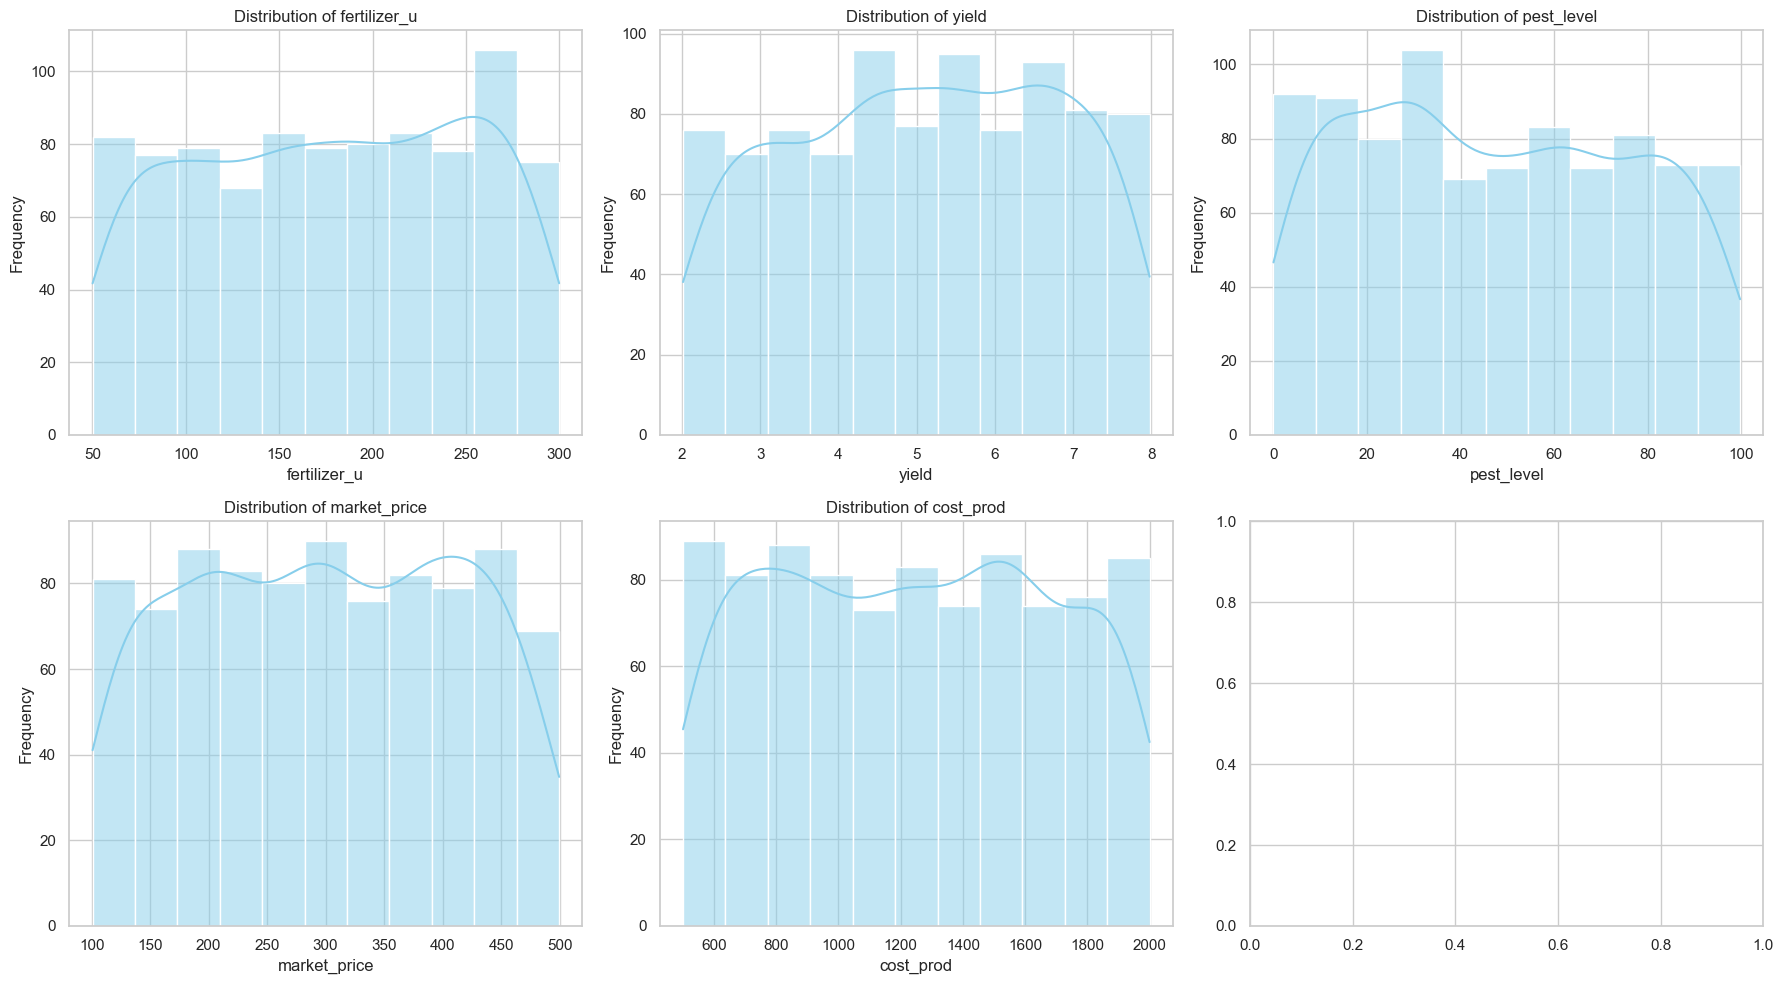

In [60]:
# Plot histograms with KDE
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_columns):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
plt.tight_layout()
plt.show()


**Note:**

The selected variables do not look normal (Gaussian) based on their histograms.

A statistical test (Shapiro-Wilk) will be used to check if they are normally distributed.

#### *How likely is it that the data in the columns of the dataset is normally distributed or not normally distributed?*

In [61]:
from scipy.stats import shapiro

# Use the Shapiro-Wilk test on each column
for col in num_columns:
    stat, p = shapiro(df[col])
    if p > 0.05:
        print(f'{col}: Probably Gaussian (p = {p:.4f})')
    else:
        print(f'{col}: Probably NOT Gaussian (p = {p:.4f})')


fertilizer_u: Probably NOT Gaussian (p = 0.0000)
yield: Probably NOT Gaussian (p = 0.0000)
pest_level: Probably NOT Gaussian (p = 0.0000)
market_price: Probably NOT Gaussian (p = 0.0000)
cost_prod: Probably NOT Gaussian (p = 0.0000)


**Note:** 

Based on the Shapiro-Wilk test results, all numerical variables (`fertilizer_u`, `yield`, `pest_level`, `market_price`, and `cost_prod`) do not follow a normal distribution (p < 0.05 for all). 

#### **1.3.1)** Q-Q Plots:

The Q-Q plot is a graphical representation of the relationship between the quantiles of the data in each numerical column and the quantiles of a normal distribution.

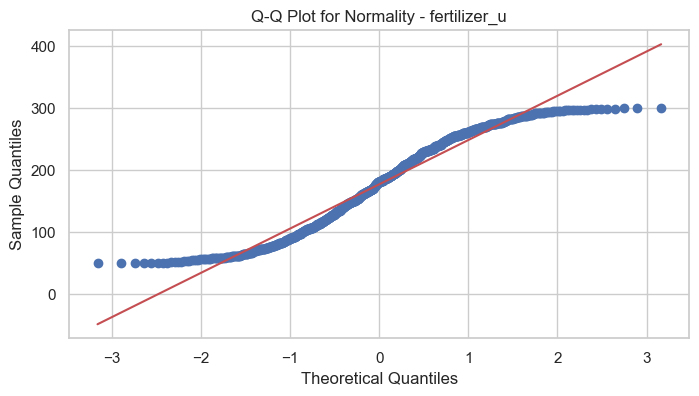

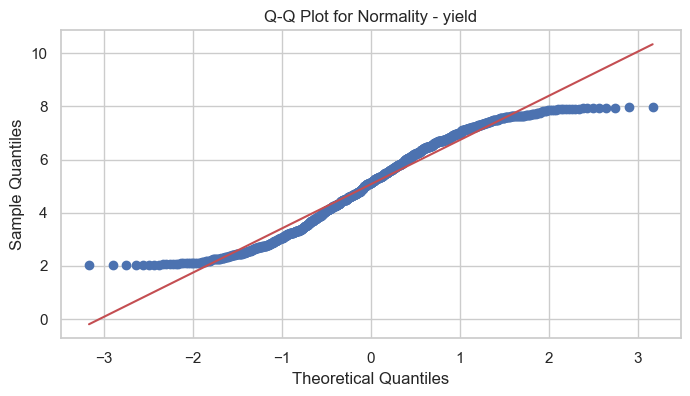

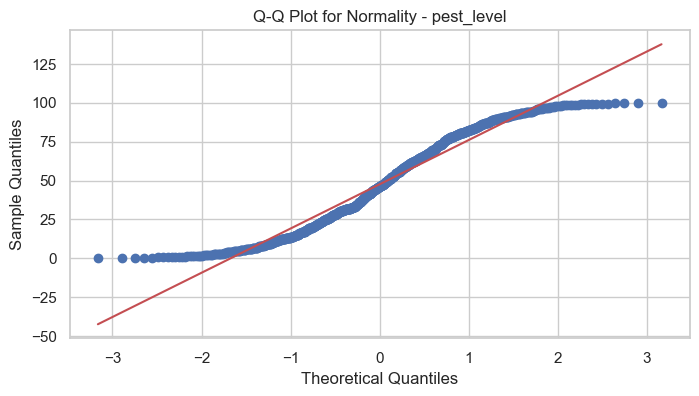

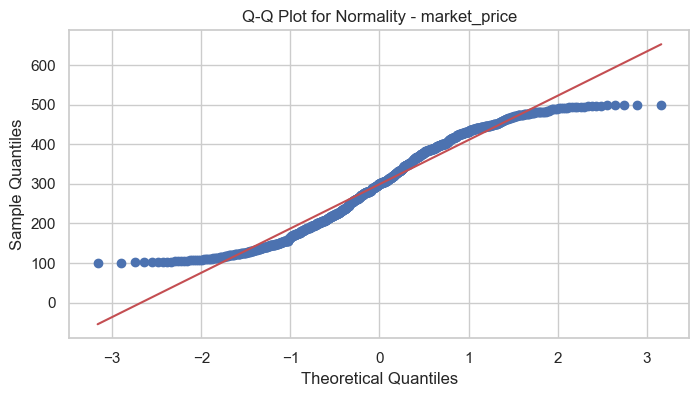

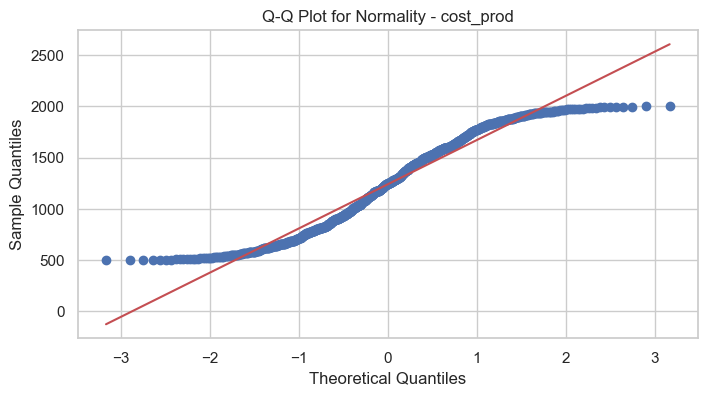

In [62]:
# Q-Q Plot to check normality visually
import scipy.stats as stats
for col in num_columns:
    plt.figure(figsize=(8, 4))
    stats.probplot(df[col], dist="norm", plot=plt)
    plt.title(f'Q-Q Plot for Normality - {col}')
    plt.xlabel('Theoretical Quantiles')
    plt.ylabel('Sample Quantiles')
    plt.grid(True)
    plt.show()


**Note:**

A visual examination of the graphs reveals clear deviations of the points from the straight line, thereby confirming the non-normal distribution of the data.

This observation is consistent with the results of the previously performed Shapiro-Wilk test, which also indicated non-normality in these variables.

#### **1.3.2)** Log Transformation

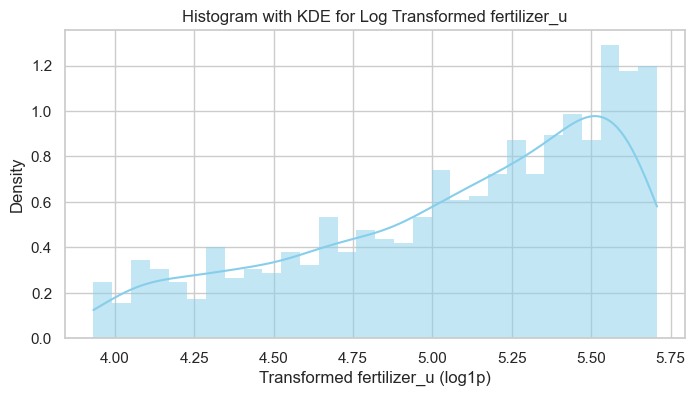

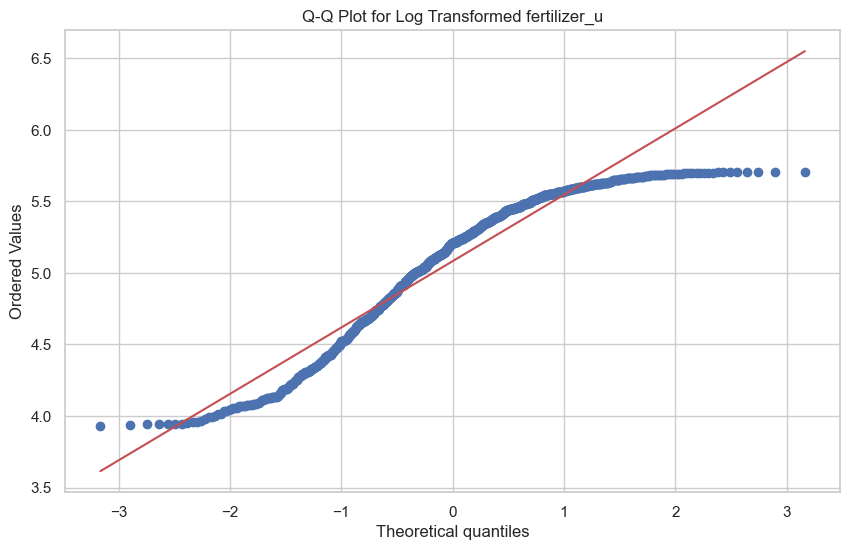

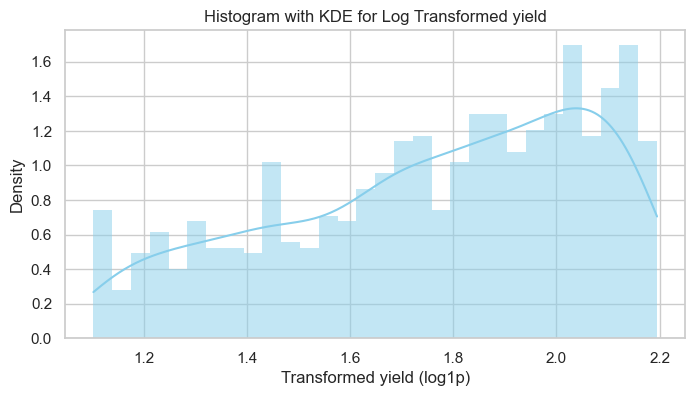

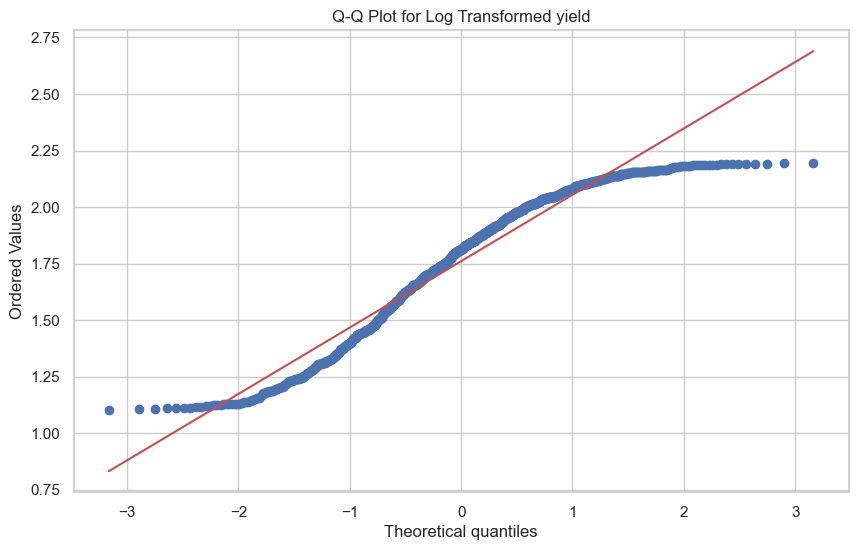

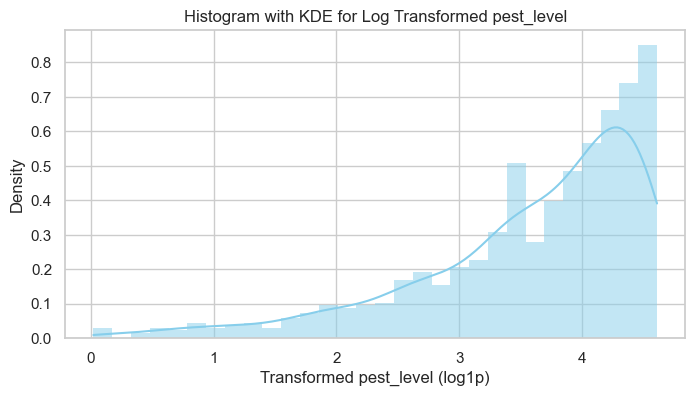

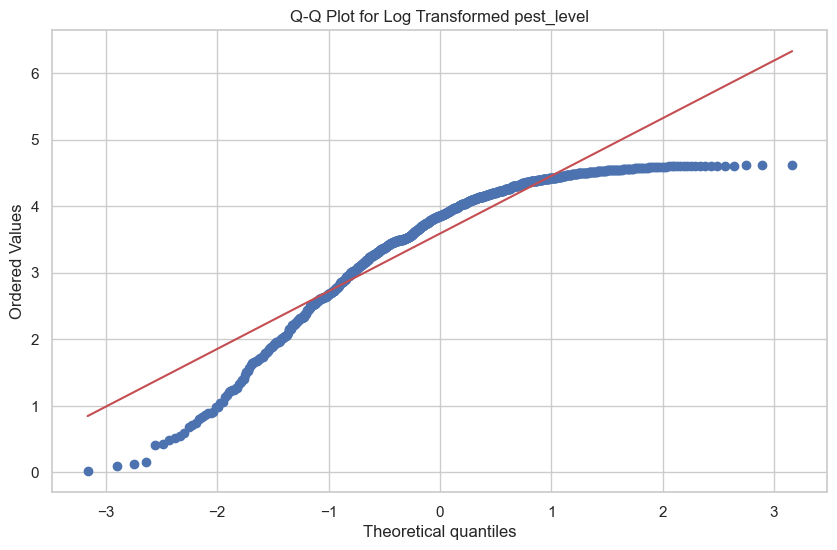

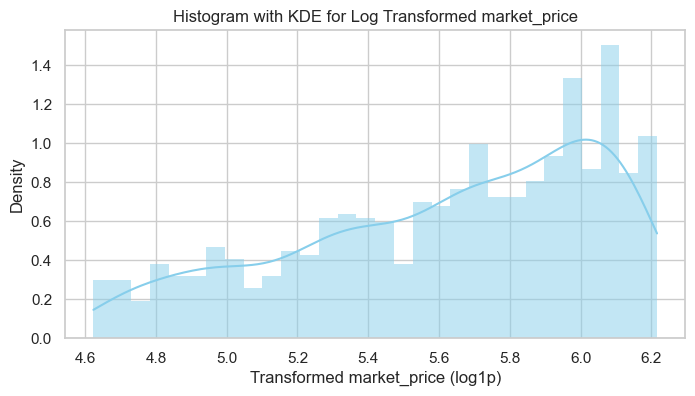

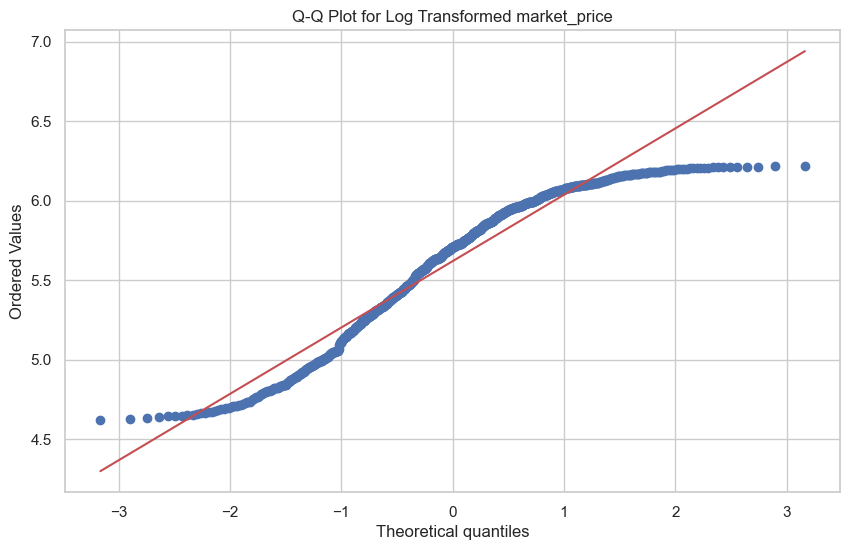

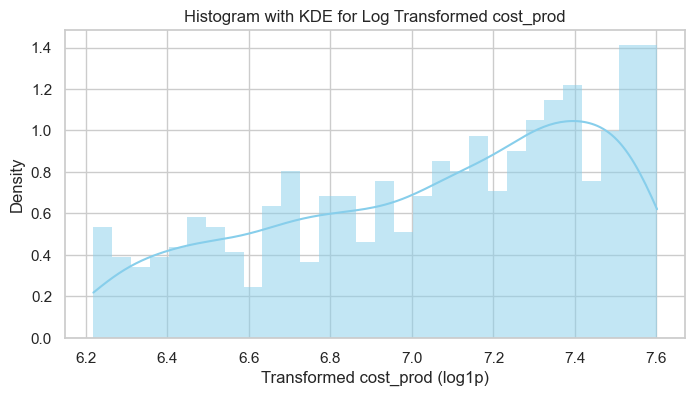

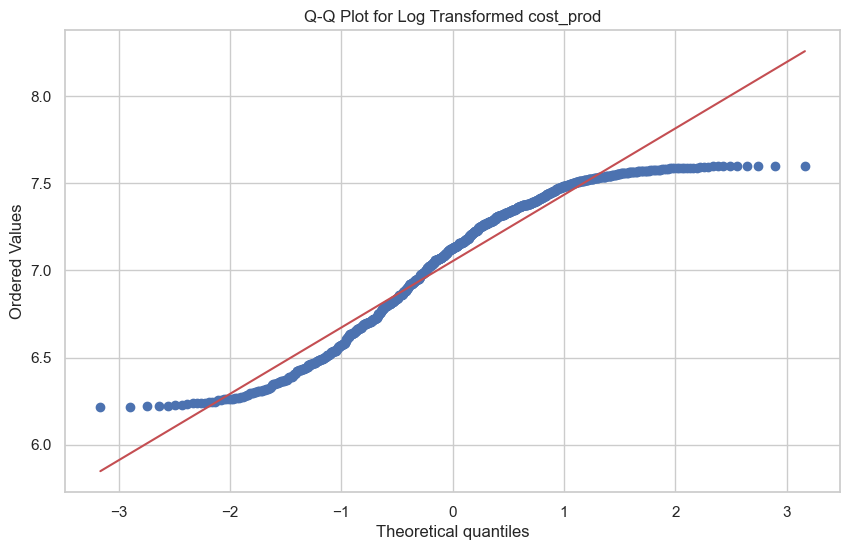

In [63]:
for col in num_columns:
    # Apply log1p transformation to the column (handles zeros and small values)
    transformed = np.log1p(df[col])
    
    # Plot histogram with KDE for the log-transformed data
    plt.figure(figsize=(8, 4))
    sns.histplot(transformed, kde=True, bins=30, color='skyblue', stat='density', linewidth=0)
    plt.title(f'Histogram with KDE for Log Transformed {col}')
    plt.xlabel(f'Transformed {col} (log1p)')
    plt.ylabel('Density')
    plt.show()
    
    # Q-Q plot to check normality after transformation
    plt.figure(figsize=(10, 6))
    stats.probplot(transformed, dist="norm", plot=plt)
    plt.title(f'Q-Q Plot for Log Transformed {col}')
    plt.show()


**Note:**

After implementing the log transformation to reduce positive skewness, the data distributions remain right-skewed, and the Q-Q plots continue to exhibit deviations from the straight line. This finding indicates that the log transform did not fully normalize the data.

### **1.4)** Probability Distributions and Density Estimation

There is a difference between the Probability Density Function (PDF) and the Cumulative Distribution Function (CDF) for statistical analysis:

**PDF (Probability Density Function):**

The PDF represents the probability distribution of a continuous random variable. It provides the probability density at a specific value of the variable.

For continuous variables, the exact probability of observing a single value is technically zero, but the PDF indicates the relative probability of observing values within an interval. The area under the PDF curve in a given interval corresponds to the probability that the variable takes a value within that range.

**CDF (Cumulative Distribution Function):**

The CDF represents the cumulative probability of the random variable. It indicates the probability that the variable takes a value less than or equal to a specific value.

Unlike the PDF, the CDF is defined for both continuous and discrete variables. The CDF is a monotonically increasing function that is always between 0 and 1.

**Question to be answered:**

#### *What are the chances that a wheat farm in this data set will produce less than or equal to 6 tons per hectare?*

A descriptive analysis shows that the average wheat yield in the data set is about 5.07 tons for each hectare. So, choosing 6 tons/ha as the average puts us just above average, which makes a meaningful comparison possible.

This value helps us understand how many farms are at or slightly above the average, which allows us to understand how yields are distributed around the average. 


In [64]:
from scipy.stats import norm

# Mean & Standard Deviation of Yield

mean_yield = (df["yield"]).mean()

std_yield = (df["yield"]).std()


# The probability of that the yield is less than or equal to 6 tons/ha 
prob = norm.cdf(6, loc=mean_yield, scale=std_yield)

print(f"Probability: {prob:.2%}")


Probability: 70.84%


In [65]:
# No assumption of normal distribution
real = (df["yield"] <= 6).mean()
print(f"Probability: {real:.2%}")


Probability: 65.28%


**Note:**

Theoretical estimation employing the cumulative distribution function (CDF) of a normal distribution, based on the dataset's mean and standard deviation, yields a probability of approximately 70.84%.

Empirical estimation, computed directly from the observed data, yielded a slightly lower probability of 65.28%.

This discrepancy is anticipated, as the Shapiro-Wilk test demonstrated that the yield variable does not adhere to a normal distribution. Consequently, while the normal-based approximation provides a useful reference under theoretical assumptions, the empirical value offers a more accurate reflection of the actual distribution of wheat yield in this dataset.

#### *In which range of wheat yield is the highest density of observations concentrated?*

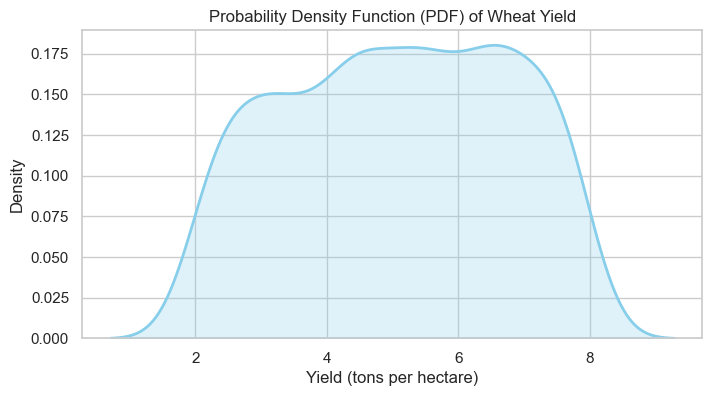

In [66]:
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x="yield", fill=True, color="skyblue", linewidth=2)

plt.title("Probability Density Function (PDF) of Wheat Yield")
plt.xlabel("Yield (tons per hectare)")
plt.ylabel("Density")
plt.grid(True)
plt.show()


**Note:**

The Probability Density Function (PDF) of wheat yield demonstrates that the highest concentration of values is observed between 6 and 8 tons per hectare, where the curve reaches its peak (just above 0.175).
However, a broader range from 4 to 8 tons/ha also exhibits relatively high density, indicating that the majority of farms in the dataset tend to produce yields within this interval.

In [67]:
# Mean & Standard Deviation of Yield
mean_yield = df["yield"].mean()
std_yield = df["yield"].std()

# Probability that the yield is between 4 and 8
prob_4_8 = norm.cdf(8, loc=mean_yield, scale=std_yield) - norm.cdf(4, loc=mean_yield, scale=std_yield)

print(f"Probability (Yield between 4 and 8): {prob_4_8:.2%}")


Probability (Yield between 4 and 8): 69.41%


**Note:**

An empirical probability estimate confirms that approximately 69.41% of the farms in the dataset have a yield within this range.

#### *How does wheat yield density vary across different soil types?*

Text(0.5, 1.0, 'Yield density by soil type')

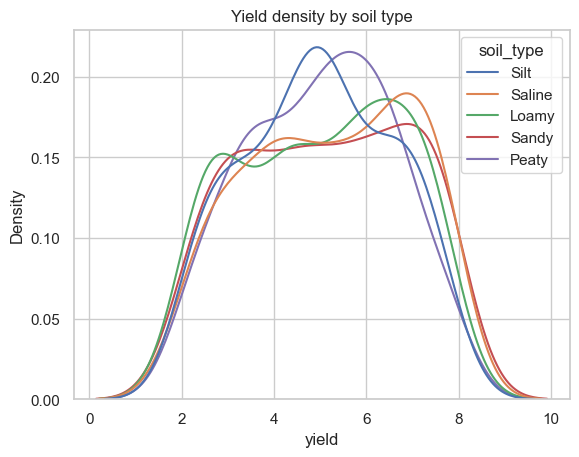

In [68]:
sns.kdeplot(data=df, x="yield", hue="soil_type", common_norm=False)
plt.title("Yield density by soil type")


**Note:**

Most soil types exhibit bell-shaped density curves, indicating similar yield distributions. However, peaty and silt soils stand out with notably higher peaks (above 0.20), suggesting that a larger proportion of farms achieve yields within a narrower, possibly higher-performing range. These soils may be more efficient or consistent in supporting wheat production.

#### *What is the probability that an observation belongs to each region?*

In [69]:
pmf_region = df['region'].value_counts(normalize=True)
print(pmf_region)


region
Europe           0.180899
South America    0.177528
North America    0.173034
Australia        0.158427
Asia             0.157303
Africa           0.152809
Name: proportion, dtype: float64


**Note:**

As previously observed in the Data Preparation section, the dataset shows a relatively balanced distribution across regions. This is confirmed by the probability mass function (PMF), where no single region dominates the dataset:

- Europe holds the largest proportion (18.09%)

- Africa has the smallest (15.28%)

  

#### *What is the joint probability that an observation belongs to a specific region and has a performance that is 'Low' or 'High'?*

In [70]:
# Categorize yield into 'Low' and 'High' based on a 6 tons/ha threshold
df["yield_category"] = pd.cut(df["yield"], bins=[-float("inf"), 6, float('inf')], labels=['Low', 'High'])

# Calculate the joint probability mass function (relative frequency) of region and yield category
pmf_joint = df.groupby(["region", "yield_category"]).size() / len(df)

# Print the probability of high-yielding farms by region
for region in df["region"].unique():
    prob = pmf_joint.get((region, "High"), 0)
    print(f"The probability of a high-yielding farm in {region} is {prob:.2%}")


The probability of a high-yielding farm in Europe is 5.84%
The probability of a high-yielding farm in North America is 6.63%
The probability of a high-yielding farm in Asia is 5.39%
The probability of a high-yielding farm in Australia is 4.94%
The probability of a high-yielding farm in Africa is 6.18%
The probability of a high-yielding farm in South America is 5.73%


**Note:**

The chances of high-yielding farms in different regions are quite similar, ranging from 4.94% in Australia to 6.63% in North America.
This suggests that no single region is much better than the rest when it comes to high yield. However, North America and Africa have slightly higher proportions of high-performing farms, which may indicate better environmental conditions, soil quality, or agricultural practices in those regions.

The following grouped bar chart illustrates the joint probability distribution of wheat yield categories across different regions. Each bar in the bar chart represents the probability of observing either a low-yielding or a high-yielding farm in a given region.

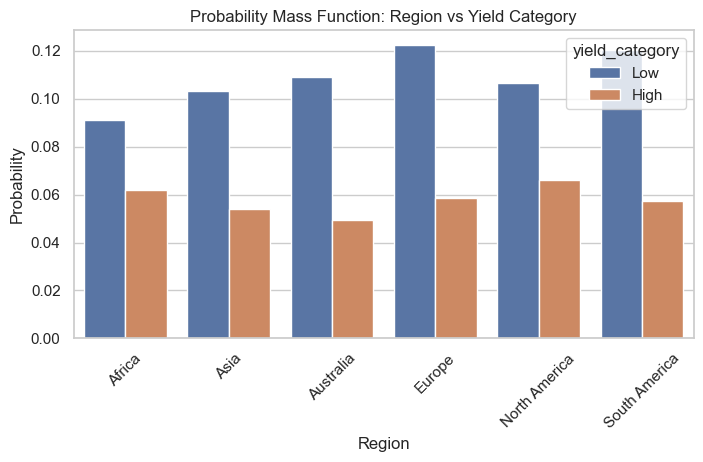

In [71]:
# Convert PMF joint to DataFrame
pmf_df = pmf_joint.reset_index(name="probability")

# Plot grouped barplot
plt.figure(figsize=(8,4))
sns.barplot(data=pmf_df, x= "region", y="probability", hue="yield_category")
plt.title("Probability Mass Function: Region vs Yield Category")
plt.xlabel("Region")
plt.ylabel("Probability")
plt.xticks(rotation=45)
plt.show()


**Note:**


- The majority of regions are characterised by a higher proportion of low-yielding farms.

- North America and Africa exhibit marginally elevated probabilities of high-yielding farms in comparison to other regions.

### **2)** **Confidence Intervals (CI):**

Select two samples, select the most appropriate confidence interval and compare the interval of the two samples. 

**Important:** 

As none of the numerical variables follow a normal distribution, a bootstrapping approach is employed to construct confidence intervals for the yield variable, which is the main focus of this project. This non-parametric method estimates the sampling distribution of a statistic through resampling with replacement, rather than relying on assumptions of normality. Given the large sample size, **Bootstrapping Confidence Intervals** offers a robust and reliable alternative to traditional parametric inference.

Although the dataset comprises 900 records, it is treated as a sample drawn from a broader population of wheat production data, which may encompass different time periods, regions, and future conditions. Since the true population variance is unknown, parametric assumptions such as normality would be inappropriate. Therefore, bootstrapping is both justified and preferable in this context, providing greater flexibility and empirical robustness when standard analytical assumptions are not fully met.

### **2.1)** Bootstrapping Confidence Interval on the Full Sample

The construction of a bootstrap confidence interval for the population mean of wheat yield was undertaken in accordance with the following steps, as delineated by Weiss (2017):

- A random sample of size n was drawn with replacement from the original dataset.

- The mean of the resampled dataset was then calculated.

- This process was repeated 1000 times to create a distribution of sample means, known as the bootstrap distribution.

- The 2.5th and 97.5th percentiles of this distribution were utilised as the endpoints of a 95% confidence interval.

This approach does not rely on normality assumptions and is particularly suitable when the population variance is unknown and the underlying distribution is skewed (Weiss, 2017).

In [72]:
# Extract the yield column from the DataFrame into a numpy array variable
yield_data = df["yield"].values # This converts the column to a numpy array

# Create a function to estimate the mean of the numerical variable
# using the bootstrapping approach

def boot_estimation(array, M=1000, ci=0.95):
    """
    Inputs:
    - array: the numerical variable
    - M: number of bootstrap samples (M: 1000)
    - ci: confidence interval (default: 95%)
    """

    # Initialise
    n = len(array)   # Number of data points
    samples = np.zeros((M,n)) # Mxn array with bootstrap samples

    # Random sampling with replacement
    for m in range(M):
        samples[m,:] = np.random.choice(array, size=n, replace=True)

    # Compute sample distribution of the means
    d_sample_boot = samples.mean(axis=1)

    # Estimate the mean (the average of the means previously computed)
    mean_boot = d_sample_boot.mean()

    # Compute limits for the confidence interval
    lim_izq = (1-ci)/2 * 100
    lim_der = (ci + (1-ci)/2) * 100

    perc_izq = np.percentile(d_sample_boot, lim_izq)
    perc_der = np.percentile(d_sample_boot, lim_der)

    # Return mean and confidence interval
    return d_sample_boot, mean_boot, [perc_izq, perc_der]

# Use the function
ci = 0.95
dist, mean, CI = boot_estimation(yield_data, M=1000, ci=ci)

# Print result
print(f'Mean: {mean:.2f}')
print(f'Confidence interval ({100*ci}%): [{CI[0]:.2f}, {CI[1]:.2f}]')

Mean: 5.07
Confidence interval (95.0%): [4.96, 5.18]


**Note:**

It can be concluded, with a confidence interval of 95%, that the true mean yield is situated within the specified calculation interval [4.96, 5.18].

### **2.2)** Comparison of Bootstrapped Confidence Intervals from Two Random Subsamples


In [73]:
# Estimate over the whole sample Mean of the original sample
ci = 0.95
dist_all, mean_all, CI_all = boot_estimation(yield_data, M=1000, ci=ci)
print(f'[Mean of the original sample]: {mean_all:.2f}, {100*ci:.0f}% CI: [{CI_all[0]:.2f}, {CI_all[1]:.2f}]\n')

# Sample 1
np.random.seed(123)
sample1 = np.random.choice(yield_data, size=int(0.9 * len(yield_data)), replace=False)
dist1, mean1, CI1 = boot_estimation(sample1, M=1000, ci=0.95)

# Sample 2
np.random.seed(456)
sample2 = np.random.choice(yield_data, size=int(0.9 * len(yield_data)), replace=False)
dist2, mean2, CI2 = boot_estimation(sample2, M=1000, ci=0.95)

# Print results
print("Comparison between two random samples:")
print(f"Sample 1 ➜ Mean: {mean1:.2f}, 95% CI: [{CI1[0]:.2f}, {CI1[1]:.2f}]")
print(f"Sample 2 ➜ Mean: {mean2:.2f}, 95% CI: [{CI2[0]:.2f}, {CI2[1]:.2f}]")


[Mean of the original sample]: 5.07, 95% CI: [4.96, 5.19]

Comparison between two random samples:
Sample 1 ➜ Mean: 5.09, 95% CI: [4.97, 5.20]
Sample 2 ➜ Mean: 5.08, 95% CI: [4.97, 5.20]


**Note:**

Two random subsamples of 90% of the data were taken to estimate the mean yield using bootstrapping with a 95% confidence interval. The estimated means and intervals obtained were found to be highly congruent with those calculated on the entire original sample. This finding suggests a high degree of stability in the estimate, thereby indicating the reliability of the mean yield estimation using this approach.

### **3)** **Inferential Statistics:**

Objective: Conduct 3 hypothesis tests (e.g., t-tests, ANOVA) to explore relationships between the features and target value.

ANOVA relies on the F-test, which compares the variability between group means to the variability within the groups.

The assumptions for conducting an ANOVA test are:

- The populations being compared are independent.

- Each population follows a normal distribution.

- The variances across groups are equal.

In this project, the dataset includes features such as pest infection level, fertilizer usage, market price, cost of production, and yield. While the primary goal is to predict crop yield, it would be reasonable to explore the influence of these variables using variance analysis. However, this approach is not appropriate here because, as previously demonstrated, the variables do not follow a normal distribution. 

Due to the lack of normality in the numerical variables, parametric tests such as ANOVA or t-tests are not applicable. Instead, I am going to focus on categorical variables to explore yield differences. 

I would like to chose Africa because an earlier exploratory analysis showed higher variability in wheat yields there, particularly due to soil type and weather. This makes it a relevant region in which to test the impact of weather conditions on yield.

### Hypotheses testing

- H0: Cloudy and Stormy conditions in Africa do not affect wheat yield

- H1: Cloudy and Stormy conditions in Africa do affect wheat yield

In [74]:
# Extract data: Region="Africa", Weather conditions = "Cloudy" or "Stormy" and Crop Yield
df_afr = df[(df["region"]=="Africa") & (df["weather"].isin(["Cloudy", "Stormy"]))]
df_afr

,region,weather,soil_type,fertilizer_u,yield,pest_level,market_price,cost_prod,score,yield_category
16,Africa,Stormy,Silt,185.636451,6.684391,61.923903,400.104318,1949.838378,1,High
34,Africa,Cloudy,Saline,294.515454,2.943958,96.226145,413.000058,983.487237,1,Low
63,Africa,Cloudy,Sandy,96.680824,7.714803,78.096386,383.559645,1026.166435,5,High
69,Africa,Stormy,Silt,210.668664,3.899298,94.317482,387.173076,503.485109,3,Low
83,Africa,Cloudy,Saline,140.923281,3.148566,71.284600,184.914257,1525.962695,1,Low
87,Africa,Stormy,Loamy,249.648318,7.267907,21.088623,105.752494,606.556132,3,High
137,Africa,Stormy,Sandy,57.778900,6.222754,24.787336,347.667218,1211.114396,5,High
149,Africa,Stormy,Loamy,266.596629,5.673549,9.319612,403.724342,1847.219667,3,Low
158,Africa,Stormy,Silt,251.849008,4.313681,5.055919,264.946595,510.564372,2,Low
163,Africa,Stormy,Loamy,50.047100,6.354355,66.279627,244.157616,855.196378,4,High


In [75]:
# Drop all columns except weather conditions and yield 
df_afr = df_afr[["weather", "yield"]]
df_afr

,weather,yield
16,Stormy,6.684391
34,Cloudy,2.943958
63,Cloudy,7.714803
69,Stormy,3.899298
83,Cloudy,3.148566
87,Stormy,7.267907
137,Stormy,6.222754
149,Stormy,5.673549
158,Stormy,4.313681
163,Stormy,6.354355


In [76]:
# Create two dataframes
df_afr_cloudy = df_afr[df_afr["weather"]=="Cloudy"]
df_afr_stormy = df_afr[df_afr["weather"]=="Stormy"]

# Remove unused columns
df_afr_cloudy.drop(columns=["weather"], inplace=True)
df_afr_stormy.drop(columns=["weather"], inplace=True)

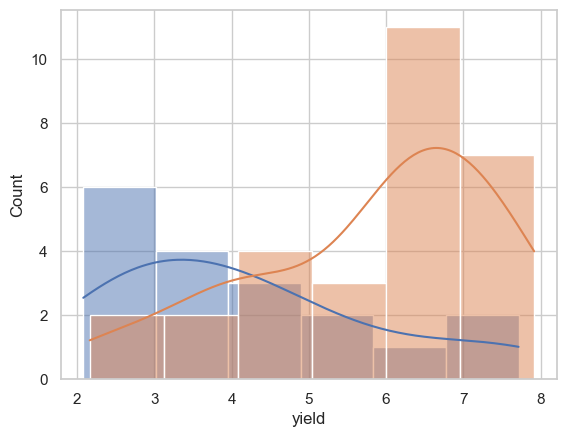

In [77]:
# Plot the histograms of these dataframes
sns.histplot(df_afr_cloudy["yield"], kde=True, label="Cloudy");
sns.histplot(df_afr_stormy["yield"], kde=True, label="Stormy");

**Note:**

As neither variable exhibits a normal distribution, the t-test or z-test cannot be used.

### Implement hypothesis test to compare both means using bootstrapping approach

In [78]:
def bootstrap_mean_diff(x, y, M=1000, ci=95, random_seed=123):
    """
    Perform bootstrap test to compare means of two samples.

    Parameters:
        x, y : arrays of numerical values
        M : number of bootstrap iterations
        ci : confidence interval percentage (e.g., 95)
        random_seed : reproducibility

    Returns:
        mean_diff_obs : observed difference in means
        p_value : two-sided p-value
        ci_lower, ci_upper : confidence interval bounds
    """

    # Set seed
    np.random.seed(random_seed)

    # x, y to numpy arrays
    x = np.array(x)
    y = np.array(y)

    # Compute difference of the means
    mean_diff_obs = np.mean(x) - np.mean(y)

    # Combine both samples
    combined = np.concatenate([x, y])
    n_x = len(x)
    n_y = len(y)

    # Bootstrap distribution
    mean_diffs = []
    for _ in range(M):
        sample_x = np.random.choice(combined, size=n_x, replace=True)
        sample_y = np.random.choice(combined, size=n_y, replace=True)
        mean_diffs.append(np.mean(sample_x) - np.mean(sample_y))

    mean_diffs = np.array(mean_diffs)

    # Compute p-value (two-sided test)
    p_value = np.mean(np.abs(mean_diffs) >= np.abs(mean_diff_obs))

    # Confidence interval
    lower_bound = np.percentile(mean_diffs, (100 - ci) / 2)
    upper_bound = np.percentile(mean_diffs, 100 - (100 - ci) / 2)

    # Optional plot
    plt.hist(mean_diffs, bins=50, alpha=0.7, edgecolor="black")
    plt.axvline(mean_diff_obs, color="red", linestyle="--", label="Observed diff")
    plt.axvline(lower_bound, color="blue", linestyle="--", label=f'{ci}% CI')
    plt.legend()
    print(f"p-value: {p_value:.4f}")



p-value: 0.0030


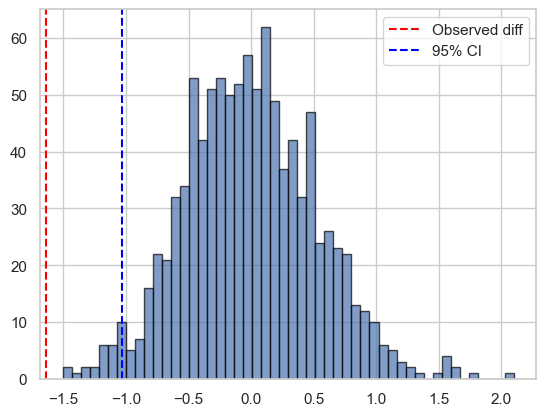

In [79]:
bootstrap_mean_diff(df_afr_cloudy["yield"], df_afr_stormy["yield"], M=1000, ci=95, random_seed=123)

**Notes:**

As the p-value (0.0030) is less than the 0.05 significance level, the null hypothesis is rejected. This suggests that there is a statistically significant difference in wheat yields under cloudy and stormy conditions in Africa. Therefore, the alternative hypothesis is that weather conditions affect wheat yields in this region.

### **4)** **Correlation Analysis:**

Objective: Investigate correlations and Linear Regression between features and the target value available in the dataset to identify potential predictors.

**Note:**

Correlation analysis was previously conducted between the numerical features and the target variable (wheat yield) during the data preparation phase, specifically in the exploratory data analysis (EDA) section. The results showed that there was little linear correlation (close to zero) between the key features, such as fertiliser usage, pest infestation level, market price and production cost, and wheat yield.

This indicates that there is no strong linear relationship between the features and the target variable. Therefore, it is expected that a linear regression model will perform poorly for this dataset.

Nevertheless, a linear regression model will be applied and evaluated to confirm that it is not a suitable approach for predicting crop yield in this context.

In order to align with the requirements of the Machine Learning module, the model will be implemented using hyperparameter tuning via GridSearchCV. It will then be evaluated using two different train-test splits (75/25 and 80/20) and validated using 10-fold cross-validation. This method provides a more robust and statistically reliable performance estimate by averaging results across multiple data partitions.

In [80]:
def evaluate_lr_model(X_train, X_test, y_train, y_test, split_name):
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2 = r2_score(y_test, y_pred_test)
    mae = mean_absolute_error(y_test, y_pred_test)
    
    print(f"{split_name} Train RMSE: {train_rmse:.2f} tons/ha")
    print(f"{split_name} Test RMSE: {test_rmse:.2f} tons/ha")
    print(f"{split_name} Test R^2: {r2:.2f}")
    
    return model, train_rmse, test_rmse, r2, mae

# Prepare data splits
X = df_scaled.drop("yield", axis=1)
y = df_scaled["yield"]

X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, test_size=0.25, random_state=123)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.20, random_state=456)

# Evaluate on both splits
model1, train_rmse1, test_rmse1, r2_1, mae_1 = evaluate_lr_model(X_train1, X_test1, y_train1, y_test1, "Split 75/25")
model2, train_rmse2, test_rmse2, r2_2, mae_2 = evaluate_lr_model(X_train2, X_test2, y_train2, y_test2, "Split 80/20")

# 10-fold CV to evaluate generalization
kf = KFold(n_splits=10, shuffle=True, random_state=123)
lr_cv_rmse = -cross_val_score(LinearRegression(), X, y, scoring='neg_root_mean_squared_error', cv=kf).mean()
print(f"10-Fold CV RMSE: {lr_cv_rmse:.2f} tons/ha")

# Store Linear Regression results
results_lr = []

results_lr.append({
    "Model": "Linear Regression (Scaled, 75/25)",
    "RMSE": test_rmse1,
    "R2": r2_1,
    "MAE": mae_1
})

results_lr.append({
    "Model": "Linear Regression (Scaled, 80/20)",
    "RMSE": test_rmse2,
    "R2": r2_2,
    "MAE": mae_2
})

results_lr.append({
    "Model": "Linear Regression (Scaled, CV-10)",
    "RMSE": lr_cv_rmse,
    "R2": np.nan,  
    "MAE": np.nan  
})



Split 75/25 Train RMSE: 1.65 tons/ha
Split 75/25 Test RMSE: 1.78 tons/ha
Split 75/25 Test R^2: -0.08
Split 80/20 Train RMSE: 1.66 tons/ha
Split 80/20 Test RMSE: 1.76 tons/ha
Split 80/20 Test R^2: -0.04
10-Fold CV RMSE: 1.71 tons/ha


**Note:**

The linear regression model, which was trained using scaled and dummy-encoded data, demonstrated comparable performance on the training and test sets (with root mean square errors (RMSEs) of 1.65 and 1.78 tons/ha, respectively), suggesting that there was no significant overfitting. However, the negative R² score on the test set (-0.08) suggests that the model performs worse than a simple mean yield prediction for all observations.

Given that the average wheat yield in the dataset is 5.07 tonnes per hectare, an RMSE of approximately 1.7–1.8 tonnes per hectare represents a substantial prediction error. These results are consistent with the earlier correlation analysis, which showed weak or negligible linear relationships between the predictors (e.g. fertiliser use, pest infestation and market price) and yield. Therefore, it can be concluded that linear regression is not an appropriate model for capturing the patterns in this dataset and that more flexible, non-linear models may be better suited to yield prediction.

# <center>Machine Learning</center>

### **1)** Supervised/ Unsupervised


The present project is based on the provided dataset and the chosen main objective: Analyse the impact of environmental factors, soil characteristics and agricultural practices on wheat yield using predictive machine learning models. One of the specific objectives is using a supervised machine learning approach, develop and evaluate predictive models that accurately estimate wheat yield (tons/ha) based on environmental conditions, soil properties, fertilizer usage, and pest control.

As Müller and Guido (2016, p. 2) state, "Supervised learning is used whenever we want to predict a certain outcome from a given input and we have examples of input/output pairs." This justifies its use in this case, since the dataset contains input variable attributes paired with corresponding wheat yield outcomes. Furthermore, the authors explain that the objective of regression tasks is to predict a continuous variable, which is applicable here since wheat yield is a continuous measure representing a range of possible outcomes.

Supervised learning relies on labelled data, whereby each observation is associated with a known output. In contrast, unsupervised learning seeks patterns in unlabelled data. Since the objective is to predict a measurable output (yield) and preserve the interpretability of predictors such as weather and fertiliser use, supervised learning is more suitable. Techniques such as PCA (an unsupervised method that disregards outcome labels) could obscure the influence of specific variables, making it more difficult to derive actionable insights.

#### **1.1)** Define the features and targets, and create two training and testing splits (75% training / 25% testing and 80% training / 20% testing)

**Dependent Variable (Target):** `yield` (Wheat Yield in tons/ha)

**Independent Variables (Features):** `region` (Region - categorical), `weather` (Weather Conditions - categorical), `soil_type` (Soil Type - categorical), `fertilizer_u` (Fertiliser Usage (kg/ha)), `pest_level` (Pest Infestation Level (%))`market_price` (Market Price per Ton ($)) and

`cost_prod` (Production Cost ($/ha))

**Note:** During the Data Preparation phase, the categorical features (`region`, `weather` and `soil type`) were encoded using one-hot encoding (`pd.get_dummies()`). The resulting dataset (`df_copy`) contains only numerical features and can be used as input for machine learning models.

In [81]:
# For raw (unscaled) data
X = df_copy.drop("yield", axis=1)
y = df_copy["yield"]

X_train1_copy, X_test1_copy, y_train1_copy, y_test1_copy = train_test_split(X, y, test_size=0.25, random_state=123)
X_train2_copy, X_test2_copy, y_train2_copy, y_test2_copy = train_test_split(X, y, test_size=0.20, random_state=456)


In [82]:
X_train1_copy.shape, X_test1_copy.shape, y_train1_copy.shape, y_test1_copy.shape

((667, 20), (223, 20), (667,), (223,))

In [83]:
X_train2_copy.shape, X_test2_copy.shape, y_train2_copy.shape, y_test2_copy.shape

((712, 20), (178, 20), (712,), (178,))

### **2)** Model Choice

According to Müller and Guido (2016), random forests are among the most widely used machine learning methods for regression and classification tasks. They are powerful and often deliver strong performance without requiring extensive hyperparameter tuning or feature scaling.

During the exploratory data analysis (EDA) phase, a correlation analysis was conducted between the numerical features and the target variable (wheat yield). The results revealed little to no linear correlation between key predictors such as fertiliser usage, pest infestation level, market price, production cost and wheat yield.

This lack of strong linear relationships suggests that linear regression models may perform poorly on this dataset, as was found in an earlier phase of the study, 'Statistics Techniques for Data Analysis'. Consequently, more flexible, nonlinear models such as Random Forests are expected to capture the complex patterns in the data more effectively and provide more accurate yield predictions.

#### **2.1)** Hyperparameter tuning with GridSearchCV

In [84]:
param_grid = {
    'n_estimators': [100, 200],          # Number of trees
    'max_depth': [None, 10, 20],         # Tree depth
    'min_samples_split': [2, 5]          # Minimum samples to split a node
}

# 5-fold cross-validation for hyperparameter tuning
grid_rf_copy = GridSearchCV(RandomForestRegressor(random_state=123),
                       param_grid,
                       cv=5,
                       scoring='neg_root_mean_squared_error',
                       n_jobs=-1)

grid_rf_copy.fit(X_train1_copy, y_train1_copy)          # Train on first split
best_rf_copy = grid_rf_copy.best_estimator_        # Get best model


### **3)** Evaluation function for Random Forest on different data splits

In [85]:
def evaluate_model(name, model, X_test_copy, y_test_copy):
    preds = model.predict(X_test_copy)
    rmse = np.sqrt(mean_squared_error(y_test_copy, preds))
    r2 = r2_score(y_test_copy, preds)
    mae = mean_absolute_error(y_test_copy, preds)
    return {
        "Model": name,
        "RMSE": rmse,
        "R2": r2,
        "MAE": mae
    }


#### **3.1)** Evaluate model on both train-test splits

In [86]:
results_copy = []

results_copy.append(evaluate_model("Random Forest (Raw, 75/25)", best_rf_copy, X_test1_copy, y_test1_copy))
results_copy.append(evaluate_model("Random Forest (Raw, 80/20)", best_rf_copy, X_test2_copy, y_test2_copy))


#### **3.2)** 10-fold cross-validation on entire dataset

In [87]:
cv = KFold(n_splits=10, shuffle=True, random_state=123)

cv_results_copy = cross_validate(
    best_rf_copy, 
    X, y,
    scoring={
        'rmse': 'neg_root_mean_squared_error',
        'r2': 'r2',
        'mae': 'neg_mean_absolute_error'
    },
    cv=cv,
    return_train_score=False
)

results_copy.append({
    "Model": "Random Forest (Raw, CV-10)",
    "RMSE": -cv_results_copy['test_rmse'].mean(),
    "R2": cv_results_copy['test_r2'].mean(),
    "MAE": -cv_results_copy['test_mae'].mean()
})


### **4)** Display the results in a table and provide a visual comparison of the RMSE

                        Model      RMSE        R2       MAE
0  Random Forest (Raw, 75/25)  1.756398 -0.058367  1.499691
1  Random Forest (Raw, 80/20)  1.256151  0.465385  1.038608
2  Random Forest (Raw, CV-10)  1.722824 -0.045246  1.480799


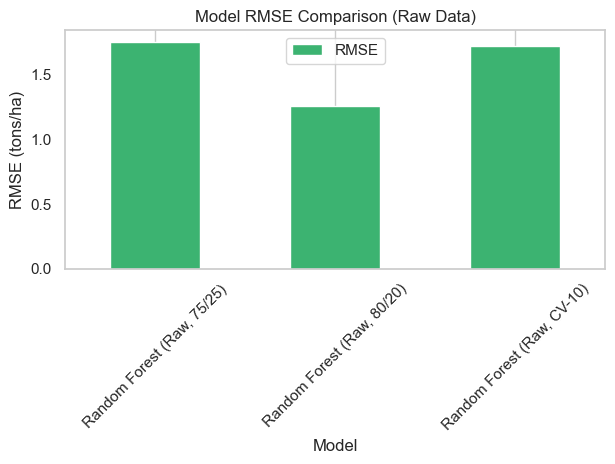

In [88]:
results_copy_df = pd.DataFrame(results_copy)
print(results_copy_df)

results_copy_df.set_index("Model")[["RMSE"]].plot(
    kind="bar",
    color="mediumseagreen",
    title="Model RMSE Comparison (Raw Data)"
)
plt.ylabel("RMSE (tons/ha)")  
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


### **5)** Overfitting Evaluation

In [89]:
# 75/25 split
best_rf_copy.fit(X_train1_copy, y_train1_copy)

train_preds_raw1 = best_rf_copy.predict(X_train1_copy)
train_rmse_raw1 = np.sqrt(mean_squared_error(y_train1_copy, train_preds_raw1))
print(f"[Raw Data] Train RMSE (75/25 split): {train_rmse_raw1:.2f} tons/ha")

test_preds_raw1 = best_rf_copy.predict(X_test1_copy)
test_rmse_raw1 = np.sqrt(mean_squared_error(y_test1_copy, test_preds_raw1))
print(f"[Raw Data] Test RMSE (75/25 split): {test_rmse_raw1:.2f} tons/ha")

# 80/20 split
best_rf_copy.fit(X_train2_copy, y_train2_copy)

train_preds_raw2 = best_rf_copy.predict(X_train2_copy)
train_rmse_raw2 = np.sqrt(mean_squared_error(y_train2_copy, train_preds_raw2))
print(f"[Raw Data] Train RMSE (80/20 split): {train_rmse_raw2:.2f} tons/ha")

test_preds_raw2 = best_rf_copy.predict(X_test2_copy)
test_rmse_raw2 = np.sqrt(mean_squared_error(y_test2_copy, test_preds_raw2))
print(f"[Raw Data] Test RMSE (80/20 split): {test_rmse_raw2:.2f} tons/ha")


[Raw Data] Train RMSE (75/25 split): 1.05 tons/ha
[Raw Data] Test RMSE (75/25 split): 1.76 tons/ha
[Raw Data] Train RMSE (80/20 split): 1.11 tons/ha
[Raw Data] Test RMSE (80/20 split): 1.75 tons/ha


### **6)** Final Comparison of All Models

Summary of Model Performance:
                               Model      RMSE        R2       MAE
0  Linear Regression (Scaled, 75/25)  1.776357 -0.082558  1.514328
1  Linear Regression (Scaled, 80/20)  1.755140 -0.043713  1.493642
2  Linear Regression (Scaled, CV-10)  1.709396       NaN       NaN
3         Random Forest (PCA, 75/25)  1.773829 -0.079479  1.514649
4         Random Forest (PCA, 80/20)  1.235315  0.482974  0.997080
5         Random Forest (PCA, CV-10)  1.743559 -0.070711  1.494054
6         Random Forest (Raw, 75/25)  1.756398 -0.058367  1.499691
7         Random Forest (Raw, 80/20)  1.256151  0.465385  1.038608
8         Random Forest (Raw, CV-10)  1.722824 -0.045246  1.480799


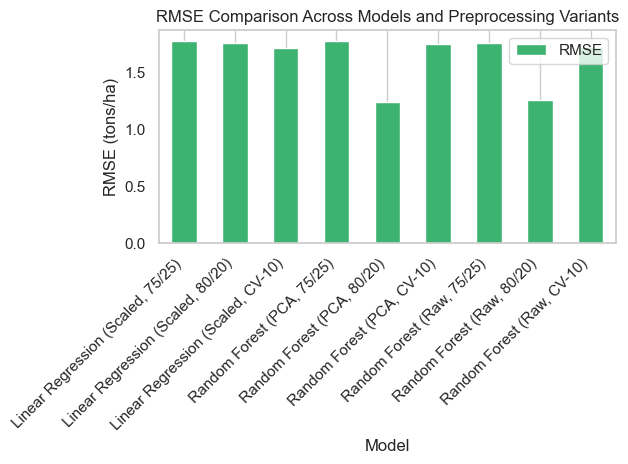

In [91]:
# Combine all model results into a single DataFrame for comparison
all_results = results_lr + results_pca + results_copy

results_df = pd.DataFrame(all_results)

print("Summary of Model Performance:")
print(results_df)

# Plot RMSE comparison
results_df.set_index("Model")[["RMSE"]].plot(
    kind="bar",
    color="mediumseagreen",
    title="RMSE Comparison Across Models and Preprocessing Variants"
)
plt.ylabel("RMSE (tons/ha)")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


### **7)** Feature importances computed from a random forest

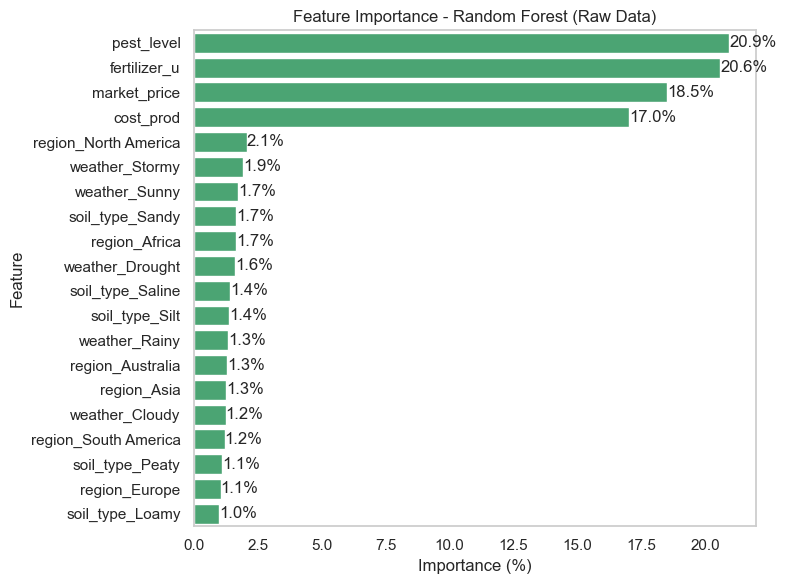

In [92]:
# Create DataFrame for feature importance from the trained Random Forest model on raw data
feat_imp_copy = pd.DataFrame({
    'Feature': X_train1_copy.columns,  # Use columns from training data
    'Importance (%)': 100 * best_rf_copy.feature_importances_
})

# Sort features by importance descending
feat_imp_copy.sort_values(by='Importance (%)', ascending=False, inplace=True)

# Plot
plt.figure(figsize=(8,6))
ax = sns.barplot(data=feat_imp_copy, y='Feature', x='Importance (%)', color='mediumseagreen')
ax.grid(axis='x')

# Add importance values on each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.title('Feature Importance - Random Forest (Raw Data)')
plt.xlabel('Importance (%)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


### **Which variables have the greatest impact on predicting performance?**

According to the Random Forest model, the most significant variables are as follows:

The pest level was recorded at 20.9%.

Fertilizer_U constituted 20.6% of the sample.

The market price constituted 18.5% of the total.

The cost of production is 17.0% of the total.

Collectively, these four variables account for over 75% of the total importance of the model, a finding that merits further investigation.

# <center>References</center>

Gatsoulis, Y. (2016) A Little Book of Python for Multivariate Analysis. [online] Version 0.1. Available at: https://python-for-multivariate-analysis.readthedocs.io/ (Accessed: 10 May 2025).

Molin, S. (2021) Hands-On Data Analysis with Pandas: A Python data science handbook for data collection, wrangling, analysis, and visualization. Birmingham: Packt Publishing Ltd.

Müller, A.C. and Guido, S. (2016) Introduction to Machine Learning with Python. 1st edn. Sebastopol, CA: O’Reilly Media.

W3Schools (2024) Correlation Matrix in Data Science. W3Schools. Available at: https://www.w3schools.com/datascience/ds_stat_correlation_matrix.asp (Accessed: 10 May 2025).

Waskom, M. (n.d.) Visualizing statistical relationships – Seaborn 0.11.2 documentation. Available at: https://seaborn.pydata.org/tutorial/relational.html (Accessed: 12 May 2025).

Weiss, N.A. (2017) Statistics. 10th edn. Global edition. Harlow, England: Pearson Education Limited.